In [2]:
# ============================================================
# 1. KÜTÜPHANELERİN KURULMASI VE ORTAM KONTROLÜ
# HOG + LBP + KAZE -> SVM / Random Forest
# Ağız Bölgesi Deepfake Tespiti
# ============================================================

!pip install -q --upgrade scikit-image scikit-learn joblib

import os
import sys
import random
import warnings
import platform

import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import (
    GroupShuffleSplit,
    GridSearchCV,
    GroupKFold
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

# Tekrarlanabilir sonuçlar için sabit seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Grafik ayarları
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 120

print("✅ Kütüphaneler başarıyla yüklendi.")
print("-" * 50)
print("Python sürümü       :", sys.version.split()[0])
print("İşletim sistemi     :", platform.system())
print("OpenCV sürümü       :", cv2.__version__)
print("NumPy sürümü        :", np.__version__)
print("Pandas sürümü       :", pd.__version__)

# KAZE özelliğinin kullanılabilirliğini kontrol et
try:
    kaze_test = cv2.KAZE_create()
    print("KAZE kontrolü       : ✅ Kullanılabilir")
except Exception as error:
    print("KAZE kontrolü       : ❌ Hata")
    print(error)

print("-" * 50)
print("Deney seed değeri   :", SEED)
print("✅ Ortam kontrolü tamamlandı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.1 MB/s eta 0:00:00
✅ Kütüphaneler başarıyla yüklendi.
--------------------------------------------------
Python sürümü       : 3.12.13
İşletim sistemi     : Linux
OpenCV sürümü       : 5.0.0
NumPy sürümü        : 2.0.2
Pandas sürümü       : 2.2.2
KAZE kontrolü       : ❌ Hata
module 'cv2' has no attribute 'KAZE_create'
--------------------------------------------------
Deney seed değeri   : 42
✅ Ortam kontrolü tamamlandı.


In [3]:
# ============================================================
# KAZE UYUMLULUK DÜZELTMESİ
# OpenCV 4 ve OpenCV 5 ile uyumlu
# ============================================================

def create_kaze():
    """
    OpenCV sürümüne uygun KAZE nesnesi oluşturur.
    """

    # OpenCV 4.x
    if hasattr(cv2, "KAZE_create"):
        return cv2.KAZE_create()

    # OpenCV 5.x
    elif hasattr(cv2, "KAZE") and hasattr(cv2.KAZE, "create"):
        return cv2.KAZE.create()

    else:
        raise RuntimeError(
            "Bu OpenCV sürümünde KAZE oluşturma fonksiyonu bulunamadı."
        )


try:
    kaze_detector = create_kaze()

    print("✅ KAZE başarıyla oluşturuldu.")
    print("OpenCV sürümü:", cv2.__version__)
    print("KAZE nesnesi :", type(kaze_detector))

except Exception as error:
    print("❌ KAZE oluşturulamadı.")
    print("Hata:", error)

❌ KAZE oluşturulamadı.
Hata: Bu OpenCV sürümünde KAZE oluşturma fonksiyonu bulunamadı.


In [4]:
# ============================================================
# OPENCV SÜRÜMÜNÜ KAZE İLE UYUMLU HALE GETİRME
# ============================================================

!pip uninstall -y opencv-python opencv-python-headless \
    opencv-contrib-python opencv-contrib-python-headless

!pip install -q --no-deps opencv-contrib-python-headless==4.10.0.84

print("✅ OpenCV 4.10 kuruldu.")
print("⚠️ Şimdi çalışma ortamı yeniden başlatılacak.")

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 MB 12.3 MB/s eta 0:00:00
✅ OpenCV 4.10 kuruldu.
⚠️ Şimdi çalışma ortamı yeniden başlatılacak.


In [ ]:
import os
import signal

os.kill(os.getpid(), signal.SIGKILL)

In [1]:
# OpenCV ve KAZE kontrolü

import cv2

print("OpenCV sürümü:", cv2.__version__)

try:
    kaze_detector = cv2.KAZE_create()

    print("✅ KAZE başarıyla oluşturuldu.")
    print("KAZE nesnesi:", type(kaze_detector))

except Exception as error:
    print("❌ KAZE oluşturulamadı.")
    print("Hata:", error)

OpenCV sürümü: 4.10.0
✅ KAZE başarıyla oluşturuldu.
KAZE nesnesi: <class 'cv2.KAZE'>


In [2]:
# ============================================================
# 2. GOOGLE DRIVE BAĞLANTISI
# ============================================================

from google.colab import drive
import os

DRIVE_ROOT = "/content/drive"

drive.mount(DRIVE_ROOT, force_remount=False)

MY_DRIVE = os.path.join(DRIVE_ROOT, "MyDrive")

if os.path.isdir(MY_DRIVE):
    print("✅ Google Drive başarıyla bağlandı.")
    print("Drive ana yolu:", MY_DRIVE)
else:
    print("❌ Google Drive bağlantısı kontrol edilemedi.")

Mounted at /content/drive
✅ Google Drive başarıyla bağlandı.
Drive ana yolu: /content/drive/MyDrive


In [3]:
# ============================================================
# 3. AĞIZ ROI VERİ SETİ KONTROLÜ
# ============================================================

from pathlib import Path
from collections import Counter

DATASET_DIR = Path(
    "/content/drive/MyDrive/AISC Çalışmalar/Deneyler/"
    "Dilara/Deney 1/Ağız/mouth_roi_output"
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Veri seti yolu:")
print(DATASET_DIR)
print("-" * 70)

# Klasör yolunu kontrol et
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        "❌ Veri seti klasörü bulunamadı.\n"
        "Drive yolundaki Türkçe karakterleri ve klasör adlarını kontrol et."
    )

print("✅ Veri seti klasörü bulundu.")

# Alt klasörleri göster
subfolders = sorted([
    path for path in DATASET_DIR.iterdir()
    if path.is_dir()
])

print("\nBulunan doğrudan alt klasörler:")

if subfolders:
    for folder in subfolders:
        print("📁", folder.name)
else:
    print("Doğrudan alt klasör bulunamadı.")

# Tüm görüntüleri recursive olarak bul
image_paths = sorted([
    path for path in DATASET_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
])

print("\n" + "-" * 70)
print("Toplam görüntü sayısı:", len(image_paths))

if len(image_paths) == 0:
    raise ValueError("❌ Klasörde desteklenen görüntü dosyası bulunamadı.")

# Dosya uzantılarının dağılımı
extension_counts = Counter(
    path.suffix.lower() for path in image_paths
)

print("\nDosya uzantıları:")

for extension, count in sorted(extension_counts.items()):
    print(f"{extension}: {count}")

# İlk klasör düzeyine göre görüntü sayıları
folder_counts = Counter()

for image_path in image_paths:
    relative_path = image_path.relative_to(DATASET_DIR)

    if len(relative_path.parts) > 1:
        first_folder = relative_path.parts[0]
    else:
        first_folder = "[ana klasör]"

    folder_counts[first_folder] += 1

print("\nİlk klasör düzeyine göre görüntü sayıları:")

for folder_name, count in sorted(folder_counts.items()):
    print(f"{folder_name}: {count}")

# Örnek dosya yollarını göster
print("\nİlk 10 örnek görüntü:")

for image_path in image_paths[:10]:
    print("🖼️", image_path.relative_to(DATASET_DIR))

print("\n✅ Veri seti klasör kontrolü tamamlandı.")

Veri seti yolu:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output
----------------------------------------------------------------------
✅ Veri seti klasörü bulundu.

Bulunan doğrudan alt klasörler:
📁 fake
📁 real

----------------------------------------------------------------------
Toplam görüntü sayısı: 5974

Dosya uzantıları:
.jpg: 2987
.png: 2987

İlk klasör düzeyine göre görüntü sayıları:
fake: 2978
real: 2996

İlk 10 örnek görüntü:
🖼️ fake/test/debug/fake_test_fake_test_00000_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00001_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00002_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00003_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00004_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00005_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00006_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00007_face00.jpg
🖼️ fake/test/debug/fake_test_fake_test_00008_face00.jpg
🖼️ fake/test/de

In [1]:
# ============================================================
# 1. DÜZELTİLMİŞ ORTAM KURULUMU
# HOG + LBP + KAZE → SVM / Random Forest
# ============================================================

!pip uninstall -y opencv-python opencv-python-headless \
    opencv-contrib-python opencv-contrib-python-headless > /dev/null 2>&1

!pip install -q --no-deps opencv-contrib-python-headless==4.10.0.84
!pip install -q scikit-image scikit-learn joblib

import os
import sys
import cv2
import random
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 120

print("Python sürümü :", sys.version.split()[0])
print("OpenCV sürümü :", cv2.__version__)

try:
    kaze_detector = cv2.KAZE_create()
    print("✅ KAZE başarıyla oluşturuldu.")
except Exception as error:
    print("❌ KAZE hatası:", error)

print("✅ Ortam kurulumu tamamlandı.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 MB 13.5 MB/s eta 0:00:00
Python sürümü : 3.12.13
OpenCV sürümü : 4.10.0
✅ KAZE başarıyla oluşturuldu.
✅ Ortam kurulumu tamamlandı.


Sınıf ve dosya uzantısına göre dağılım:
------------------------------------------------------------
fake       | .jpg  |  1489 görüntü
fake       | .png  |  1489 görüntü
real       | .jpg  |  1498 görüntü
real       | .png  |  1498 görüntü

Alt klasörlere göre dağılım:
------------------------------------------------------------
fake/test/debug: 156
fake/test/mouth: 156
fake/train/debug: 1192
fake/train/mouth: 1192
fake/val/debug: 141
fake/val/mouth: 141
real/test/debug: 146
real/test/mouth: 146
real/train/debug: 1197
real/train/mouth: 1197
real/val/debug: 155
real/val/mouth: 155

Debug görüntüsü sayısı       : 2987
Kullanılabilir PNG ROI sayısı: 2987

PNG ROI sınıf dağılımı:
fake: 1489
real: 1498


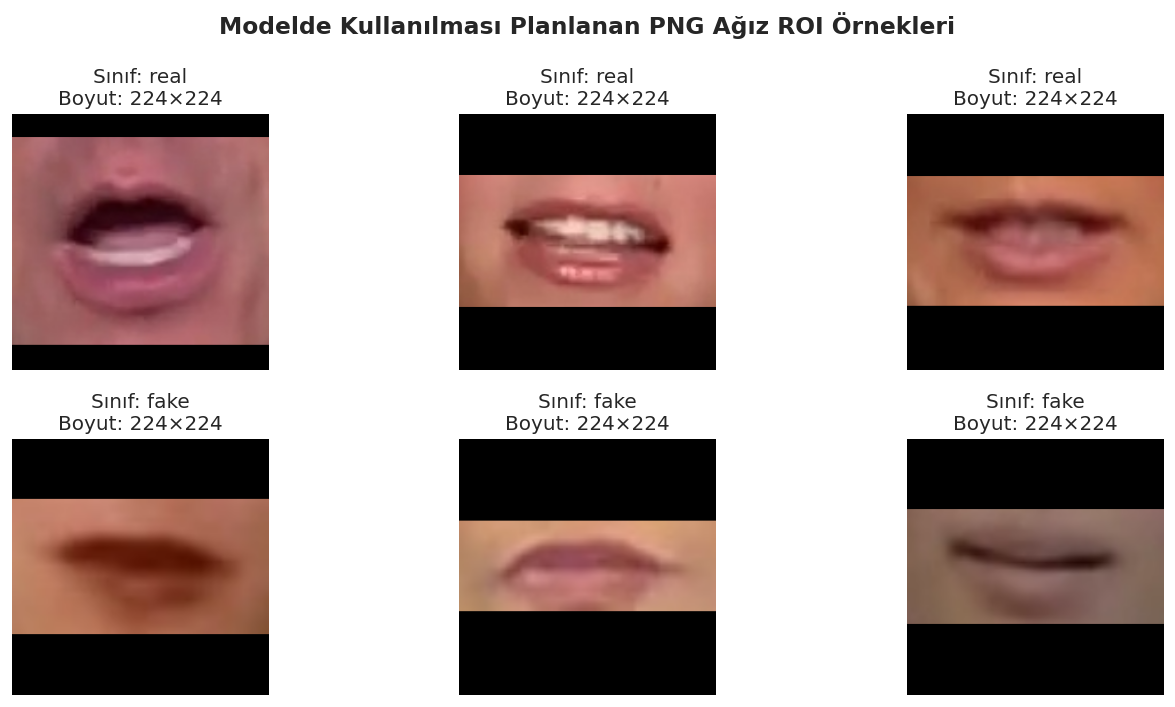

In [4]:
# ============================================================
# 4. GERÇEK ROI VE DEBUG GÖRÜNTÜLERİNİ AYIRMA
# ============================================================

from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import cv2

# Sınıf ve uzantıya göre sayım
class_extension_counts = Counter()
parent_folder_counts = Counter()

for image_path in image_paths:
    relative_path = image_path.relative_to(DATASET_DIR)

    class_name = relative_path.parts[0]
    extension = image_path.suffix.lower()

    class_extension_counts[(class_name, extension)] += 1

    relative_parent = str(relative_path.parent)
    parent_folder_counts[relative_parent] += 1

print("Sınıf ve dosya uzantısına göre dağılım:")
print("-" * 60)

for (class_name, extension), count in sorted(
    class_extension_counts.items()
):
    print(
        f"{class_name:10s} | "
        f"{extension:5s} | "
        f"{count:5d} görüntü"
    )

print("\nAlt klasörlere göre dağılım:")
print("-" * 60)

for folder_name, count in sorted(parent_folder_counts.items()):
    print(f"{folder_name}: {count}")

# Debug klasöründeki dosyaları ayır
debug_images = [
    path for path in image_paths
    if "debug" in [part.lower() for part in path.parts]
]

# Debug klasöründe bulunmayan PNG görüntüleri
roi_images = [
    path for path in image_paths
    if path.suffix.lower() == ".png"
    and "debug" not in [part.lower() for part in path.parts]
]

print("\n" + "=" * 60)
print("Debug görüntüsü sayısı       :", len(debug_images))
print("Kullanılabilir PNG ROI sayısı:", len(roi_images))

# Kullanılabilir ROI'lerin sınıf dağılımı
roi_class_counts = Counter(
    path.relative_to(DATASET_DIR).parts[0]
    for path in roi_images
)

print("\nPNG ROI sınıf dağılımı:")

for class_name, count in sorted(roi_class_counts.items()):
    print(f"{class_name}: {count}")

# PNG örneklerini görselleştir
sample_roi_paths = []

for target_class in ["real", "fake"]:
    class_samples = [
        path for path in roi_images
        if path.relative_to(DATASET_DIR).parts[0] == target_class
    ]

    sample_roi_paths.extend(class_samples[:3])

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for axis, image_path in zip(axes, sample_roi_paths):
    image = cv2.imread(str(image_path))

    if image is None:
        axis.set_title("Görüntü okunamadı")
        axis.axis("off")
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    class_name = image_path.relative_to(DATASET_DIR).parts[0]

    axis.imshow(image_rgb)
    axis.set_title(
        f"Sınıf: {class_name}\n"
        f"Boyut: {image.shape[1]}×{image.shape[0]}"
    )
    axis.axis("off")

plt.suptitle(
    "Modelde Kullanılması Planlanan PNG Ağız ROI Örnekleri",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# 5. METADATA TABLOSUNUN OLUŞTURULMASI
# real = 0, fake = 1
# ============================================================

import pandas as pd
from pathlib import Path

metadata_records = []

for image_path in roi_images:
    relative_path = image_path.relative_to(DATASET_DIR)
    parts = relative_path.parts

    # Beklenen yapı:
    # class / split / mouth / image.png
    if len(parts) < 4:
        continue

    class_name = parts[0].lower()
    split_name = parts[1].lower()
    folder_name = parts[2].lower()

    # Yalnızca gerçek ağız ROI klasörünü kullan
    if folder_name != "mouth":
        continue

    if class_name not in {"real", "fake"}:
        continue

    if split_name not in {"train", "val", "test"}:
        continue

    label = 0 if class_name == "real" else 1

    metadata_records.append({
        "image_path": str(image_path),
        "file_name": image_path.name,
        "class_name": class_name,
        "label": label,
        "split": split_name
    })

metadata_df = pd.DataFrame(metadata_records)

# Düzenli sıralama
metadata_df = metadata_df.sort_values(
    by=["split", "class_name", "file_name"]
).reset_index(drop=True)

print("✅ Metadata tablosu oluşturuldu.")
print("Toplam kayıt:", len(metadata_df))

print("\nSplit ve sınıf dağılımı:")
distribution_table = pd.crosstab(
    metadata_df["split"],
    metadata_df["class_name"],
    margins=True
)

display(distribution_table)

print("\nİlk 10 kayıt:")
display(metadata_df.head(10))

# Temel kontroller
assert len(metadata_df) == 2987, (
    f"Beklenen 2987 görüntü yerine "
    f"{len(metadata_df)} görüntü bulundu."
)

assert metadata_df["image_path"].nunique() == 2987, (
    "Tekrarlanan görüntü yolu bulundu."
)

assert set(metadata_df["class_name"].unique()) == {"real", "fake"}
assert set(metadata_df["split"].unique()) == {"train", "val", "test"}

print("\n✅ Toplam görüntü sayısı doğru: 2987")
print("✅ Tekrarlanan dosya yolu yok.")
print("✅ Sınıflar doğru: real ve fake")
print("✅ Bölümler doğru: train, val ve test")

print("\nEtiket tanımı:")
print("real → 0")
print("fake → 1")

✅ Metadata tablosu oluşturuldu.
Toplam kayıt: 2987

Split ve sınıf dağılımı:


class_name,fake,real,All
split,,,
test,156,146,302
train,1192,1197,2389
val,141,155,296
All,1489,1498,2987



İlk 10 kayıt:


,image_path,file_name,class_name,label,split
0,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00000_face00.png,fake,1,test
1,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00001_face00.png,fake,1,test
2,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00002_face00.png,fake,1,test
3,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00003_face00.png,fake,1,test
4,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00004_face00.png,fake,1,test
5,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00005_face00.png,fake,1,test
6,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00006_face00.png,fake,1,test
7,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00007_face00.png,fake,1,test
8,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00008_face00.png,fake,1,test
9,/content/drive/MyDrive/AISC Çalışmalar/Deney...,fake_test_fake_test_00009_face00.png,fake,1,test



✅ Toplam görüntü sayısı doğru: 2987
✅ Tekrarlanan dosya yolu yok.
✅ Sınıflar doğru: real ve fake
✅ Bölümler doğru: train, val ve test

Etiket tanımı:
real → 0
fake → 1


In [6]:
# ============================================================
# 6. HOG, LBP VE KAZE ÖZELLİK ÇIKARIM FONKSİYONLARI
# ============================================================

import cv2
import numpy as np

from skimage.feature import hog, local_binary_pattern


# ------------------------------------------------------------
# Sabit özellik çıkarım parametreleri
# ------------------------------------------------------------

IMAGE_SIZE = (224, 224)

# HOG parametreleri
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)

# LBP parametreleri
LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS       # 24 komşu nokta
LBP_METHOD = "uniform"
LBP_BINS = LBP_POINTS + 2         # Uniform LBP için 26 histogram kutusu

# KAZE parametreleri
KAZE_DESCRIPTOR_LENGTH = 64

# Aynı KAZE nesnesini tekrar kullan
kaze_detector = cv2.KAZE_create()


# ------------------------------------------------------------
# Görüntü okuma ve ön işleme
# ------------------------------------------------------------

def load_and_preprocess_image(image_path):
    """
    Görüntüyü okur, 224x224 boyutuna getirir
    ve gri-seviye uint8 görüntü döndürür.
    """

    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError(
            f"Görüntü okunamadı: {image_path}"
        )

    image = cv2.resize(
        image,
        IMAGE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    gray_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    return gray_image


# ------------------------------------------------------------
# HOG özellik çıkarımı
# ------------------------------------------------------------

def extract_hog_features(gray_image):
    """
    Ağız sınırları, dudak kenarları ve yönelim
    değişimlerini temsil eden HOG vektörünü çıkarır.
    """

    hog_vector = hog(
        gray_image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True
    )

    return hog_vector.astype(np.float32)


# ------------------------------------------------------------
# LBP özellik çıkarımı
# ------------------------------------------------------------

def extract_lbp_features(gray_image):
    """
    Lokal ağız ve dudak dokusunu temsil eden
    normalize edilmiş LBP histogramını çıkarır.
    """

    lbp_image = local_binary_pattern(
        gray_image,
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method=LBP_METHOD
    )

    lbp_histogram, _ = np.histogram(
        lbp_image.ravel(),
        bins=np.arange(0, LBP_BINS + 1),
        range=(0, LBP_BINS)
    )

    lbp_histogram = lbp_histogram.astype(np.float32)

    # Histogram normalizasyonu
    lbp_histogram /= (
        lbp_histogram.sum() + 1e-8
    )

    return lbp_histogram


# ------------------------------------------------------------
# KAZE özellik çıkarımı
# ------------------------------------------------------------

def extract_kaze_features(gray_image):
    """
    KAZE keypoint ve descriptor'larını çıkarır.

    Görüntü başına keypoint sayısı değiştiği için
    descriptor ortalaması ve standart sapması alınır.

    64 ortalama + 64 standart sapma = 128 özellik
    """

    keypoints, descriptors = (
        kaze_detector.detectAndCompute(
            gray_image,
            None
        )
    )

    keypoint_count = len(keypoints)

    if descriptors is None or len(descriptors) == 0:
        kaze_vector = np.zeros(
            KAZE_DESCRIPTOR_LENGTH * 2,
            dtype=np.float32
        )

        return kaze_vector, 0

    descriptors = descriptors.astype(np.float32)

    descriptor_mean = np.mean(
        descriptors,
        axis=0
    )

    descriptor_std = np.std(
        descriptors,
        axis=0
    )

    kaze_vector = np.concatenate([
        descriptor_mean,
        descriptor_std
    ])

    return kaze_vector.astype(np.float32), keypoint_count


# ------------------------------------------------------------
# HOG + LBP + KAZE özelliklerinin birleştirilmesi
# ------------------------------------------------------------

def extract_combined_features(image_path):
    """
    Tek bir ağız ROI görüntüsünden HOG, LBP ve KAZE
    özelliklerini çıkarıp tek vektörde birleştirir.

    Buradaki birleştirme kaş-göz-ağız füzyonu değildir.
    Yalnızca ağız modelinin özellik vektörüdür.
    """

    gray_image = load_and_preprocess_image(
        image_path
    )

    hog_vector = extract_hog_features(
        gray_image
    )

    lbp_vector = extract_lbp_features(
        gray_image
    )

    kaze_vector, keypoint_count = (
        extract_kaze_features(gray_image)
    )

    combined_vector = np.concatenate([
        hog_vector,
        lbp_vector,
        kaze_vector
    ]).astype(np.float32)

    feature_info = {
        "hog_length": len(hog_vector),
        "lbp_length": len(lbp_vector),
        "kaze_length": len(kaze_vector),
        "combined_length": len(combined_vector),
        "kaze_keypoint_count": keypoint_count
    }

    return combined_vector, feature_info


print("✅ Özellik çıkarım fonksiyonları oluşturuldu.")

✅ Özellik çıkarım fonksiyonları oluşturuldu.


In [7]:
# ============================================================
# 7. ÖZELLİK ÇIKARIM FONKSİYONLARININ TESTİ
# Henüz bütün veri seti işlenmez
# ============================================================

test_samples = pd.concat([
    metadata_df[
        metadata_df["class_name"] == "real"
    ].sample(
        n=3,
        random_state=SEED
    ),

    metadata_df[
        metadata_df["class_name"] == "fake"
    ].sample(
        n=3,
        random_state=SEED
    )
]).reset_index(drop=True)

test_results = []

for _, sample in test_samples.iterrows():

    combined_vector, feature_info = (
        extract_combined_features(
            sample["image_path"]
        )
    )

    test_results.append({
        "class_name": sample["class_name"],
        "file_name": sample["file_name"],
        "hog_length": feature_info["hog_length"],
        "lbp_length": feature_info["lbp_length"],
        "kaze_length": feature_info["kaze_length"],
        "combined_length": feature_info["combined_length"],
        "kaze_keypoints": feature_info[
            "kaze_keypoint_count"
        ],
        "contains_nan": np.isnan(
            combined_vector
        ).any(),
        "contains_inf": np.isinf(
            combined_vector
        ).any()
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

# Vektör boyutlarının bütün görüntülerde aynı olduğunu kontrol et
assert test_results_df["hog_length"].nunique() == 1
assert test_results_df["lbp_length"].nunique() == 1
assert test_results_df["kaze_length"].nunique() == 1
assert test_results_df["combined_length"].nunique() == 1

# NaN ve sonsuz değer kontrolü
assert not test_results_df["contains_nan"].any()
assert not test_results_df["contains_inf"].any()

print("\nÖzellik boyutları:")
print(
    "HOG:",
    test_results_df["hog_length"].iloc[0]
)

print(
    "LBP:",
    test_results_df["lbp_length"].iloc[0]
)

print(
    "KAZE:",
    test_results_df["kaze_length"].iloc[0]
)

print(
    "Birleşik ağız özellik vektörü:",
    test_results_df["combined_length"].iloc[0]
)

print("\n✅ Bütün özellik vektörleri sabit boyutlu.")
print("✅ NaN veya sonsuz değer bulunmadı.")
print("✅ Küçük ölçekli özellik çıkarım testi başarılı.")

,class_name,file_name,hog_length,lbp_length,kaze_length,combined_length,kaze_keypoints,contains_nan,contains_inf
0,real,real_train_real_train_00884_face00.png,6084,26,128,6238,9,False,False
1,real,real_train_real_train_01161_face00.png,6084,26,128,6238,14,False,False
2,real,real_val_real_val_00091_face00.png,6084,26,128,6238,3,False,False
3,fake,fake_train_fake_train_00794_face00.png,6084,26,128,6238,22,False,False
4,fake,fake_train_fake_train_00141_face00.png,6084,26,128,6238,11,False,False
5,fake,fake_train_fake_train_00114_face00.png,6084,26,128,6238,16,False,False



Özellik boyutları:
HOG: 6084
LBP: 26
KAZE: 128
Birleşik ağız özellik vektörü: 6238

✅ Bütün özellik vektörleri sabit boyutlu.
✅ NaN veya sonsuz değer bulunmadı.
✅ Küçük ölçekli özellik çıkarım testi başarılı.


In [8]:
# ============================================================
# 8. TÜM VERİ SETİNDEN HOG + LBP + KAZE ÇIKARIMI
# Sonuçlar 250 görüntülük parçalar halinde kaydedilir.
# ============================================================

import time
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm

# Sonuç klasörü
RESULTS_DIR = DATASET_DIR.parent / "HOG_LBP_KAZE_Results"
CHUNKS_DIR = RESULTS_DIR / "feature_chunks"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHUNKS_DIR.mkdir(parents=True, exist_ok=True)

# Özellik uzunlukları
HOG_LENGTH = 6084
LBP_LENGTH = 26
KAZE_LENGTH = 128
COMBINED_LENGTH = 6238

# Her checkpoint dosyasındaki görüntü sayısı
CHUNK_SIZE = 250

total_images = len(metadata_df)
total_chunks = int(np.ceil(total_images / CHUNK_SIZE))

print("Toplam görüntü     :", total_images)
print("Parça boyutu       :", CHUNK_SIZE)
print("Toplam parça sayısı:", total_chunks)
print("Kayıt klasörü      :", CHUNKS_DIR)
print("-" * 70)

start_time = time.time()
processed_now = 0
skipped_images = 0

for chunk_number, start_index in enumerate(
    range(0, total_images, CHUNK_SIZE),
    start=1
):
    end_index = min(
        start_index + CHUNK_SIZE,
        total_images
    )

    chunk_file = CHUNKS_DIR / (
        f"features_{start_index:04d}_{end_index - 1:04d}.npz"
    )

    expected_count = end_index - start_index

    # Daha önce doğru kaydedilmiş parçayı tekrar işleme
    chunk_is_valid = False

    if chunk_file.exists():
        try:
            with np.load(
                chunk_file,
                allow_pickle=False
            ) as saved_chunk:

                saved_count = len(
                    saved_chunk["global_indices"]
                )

                required_keys = {
                    "global_indices",
                    "hog_features",
                    "lbp_features",
                    "kaze_features",
                    "labels",
                    "splits",
                    "image_paths",
                    "keypoint_counts"
                }

                chunk_is_valid = (
                    saved_count == expected_count
                    and required_keys.issubset(
                        set(saved_chunk.files)
                    )
                )

        except Exception:
            chunk_is_valid = False

    if chunk_is_valid:
        print(
            f"⏭️ Parça {chunk_number}/{total_chunks} "
            f"zaten tamamlanmış: {chunk_file.name}"
        )

        skipped_images += expected_count
        continue

    print(
        f"\n▶️ Parça {chunk_number}/{total_chunks} işleniyor "
        f"({start_index}–{end_index - 1})"
    )

    chunk_metadata = metadata_df.iloc[
        start_index:end_index
    ].copy()

    chunk_hog = []
    chunk_lbp = []
    chunk_kaze = []
    chunk_labels = []
    chunk_splits = []
    chunk_paths = []
    chunk_keypoint_counts = []
    chunk_global_indices = []

    progress_bar = tqdm(
        chunk_metadata.iterrows(),
        total=len(chunk_metadata),
        desc=f"Parça {chunk_number}"
    )

    for global_index, row in progress_bar:

        combined_vector, feature_info = (
            extract_combined_features(
                row["image_path"]
            )
        )

        # Birleşik vektörü tekrar özellik bloklarına ayır
        hog_vector = combined_vector[
            0:HOG_LENGTH
        ]

        lbp_start = HOG_LENGTH
        lbp_end = HOG_LENGTH + LBP_LENGTH

        lbp_vector = combined_vector[
            lbp_start:lbp_end
        ]

        kaze_vector = combined_vector[
            lbp_end:COMBINED_LENGTH
        ]

        # Boyut kontrolleri
        if len(hog_vector) != HOG_LENGTH:
            raise ValueError(
                f"HOG boyutu hatalı: {row['image_path']}"
            )

        if len(lbp_vector) != LBP_LENGTH:
            raise ValueError(
                f"LBP boyutu hatalı: {row['image_path']}"
            )

        if len(kaze_vector) != KAZE_LENGTH:
            raise ValueError(
                f"KAZE boyutu hatalı: {row['image_path']}"
            )

        chunk_hog.append(hog_vector)
        chunk_lbp.append(lbp_vector)
        chunk_kaze.append(kaze_vector)

        chunk_labels.append(row["label"])
        chunk_splits.append(row["split"])
        chunk_paths.append(row["image_path"])
        chunk_global_indices.append(global_index)

        chunk_keypoint_counts.append(
            feature_info["kaze_keypoint_count"]
        )

    # Listeleri NumPy dizilerine dönüştür
    chunk_hog = np.asarray(
        chunk_hog,
        dtype=np.float32
    )

    chunk_lbp = np.asarray(
        chunk_lbp,
        dtype=np.float32
    )

    chunk_kaze = np.asarray(
        chunk_kaze,
        dtype=np.float32
    )

    chunk_labels = np.asarray(
        chunk_labels,
        dtype=np.int64
    )

    chunk_keypoint_counts = np.asarray(
        chunk_keypoint_counts,
        dtype=np.int32
    )

    chunk_global_indices = np.asarray(
        chunk_global_indices,
        dtype=np.int32
    )

    chunk_splits = np.asarray(
        chunk_splits,
        dtype=str
    )

    chunk_paths = np.asarray(
        chunk_paths,
        dtype=str
    )

    # Önce geçici dosyaya kaydet
    temporary_file = Path(
        str(chunk_file) + ".temporary.npz"
    )

    np.savez_compressed(
        temporary_file,
        global_indices=chunk_global_indices,
        hog_features=chunk_hog,
        lbp_features=chunk_lbp,
        kaze_features=chunk_kaze,
        labels=chunk_labels,
        splits=chunk_splits,
        image_paths=chunk_paths,
        keypoint_counts=chunk_keypoint_counts
    )

    # Dosya tam oluştuktan sonra asıl adına taşı
    temporary_file.replace(chunk_file)

    processed_now += expected_count

    elapsed_minutes = (
        time.time() - start_time
    ) / 60

    print(
        f"✅ Kaydedildi: {chunk_file.name} | "
        f"Bu oturumda işlenen: {processed_now} | "
        f"Süre: {elapsed_minutes:.2f} dakika"
    )

total_elapsed = (time.time() - start_time) / 60

print("\n" + "=" * 70)
print("✅ Özellik çıkarım aşaması tamamlandı.")
print("Bu oturumda işlenen görüntü :", processed_now)
print("Önceden işlenmiş görüntü    :", skipped_images)
print("Toplam görüntü              :", processed_now + skipped_images)
print(f"Toplam geçen süre           : {total_elapsed:.2f} dakika")
print("Parçaların kayıt yeri       :", CHUNKS_DIR)

Toplam görüntü     : 2987
Parça boyutu       : 250
Toplam parça sayısı: 12
Kayıt klasörü      : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/feature_chunks
----------------------------------------------------------------------

▶️ Parça 1/12 işleniyor (0–249)


Parça 1:   0%|          | 0/250 [00:00<?, ?it/s]

✅ Kaydedildi: features_0000_0249.npz | Bu oturumda işlenen: 250 | Süre: 4.13 dakika

▶️ Parça 2/12 işleniyor (250–499)


Parça 2:   0%|          | 0/250 [00:00<?, ?it/s]

✅ Kaydedildi: features_0250_0499.npz | Bu oturumda işlenen: 500 | Süre: 8.33 dakika

▶️ Parça 3/12 işleniyor (500–749)


...

✅ Kaydedildi: features_2250_2499.npz | Bu oturumda işlenen: 2500 | Süre: 42.15 dakika

▶️ Parça 11/12 işleniyor (2500–2749)


Parça 11:   0%|          | 0/250 [00:00<?, ?it/s]

✅ Kaydedildi: features_2500_2749.npz | Bu oturumda işlenen: 2750 | Süre: 46.39 dakika

▶️ Parça 12/12 işleniyor (2750–2986)


Parça 12:   0%|          | 0/237 [00:00<?, ?it/s]

✅ Kaydedildi: features_2750_2986.npz | Bu oturumda işlenen: 2987 | Süre: 50.44 dakika

✅ Özellik çıkarım aşaması tamamlandı.
Bu oturumda işlenen görüntü : 2987
Önceden işlenmiş görüntü    : 0
Toplam görüntü              : 2987
Toplam geçen süre           : 50.44 dakika
Parçaların kayıt yeri       : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/feature_chunks


In [9]:
# ============================================================
# 9. ÖZELLİK PARÇALARINI BİRLEŞTİRME VE DOĞRULAMA
# ============================================================

import time
import numpy as np
import pandas as pd
from pathlib import Path

merge_start_time = time.time()

# Kaydedilmiş parça dosyalarını bul
chunk_files = sorted(
    CHUNKS_DIR.glob("features_*.npz")
)

print("Bulunan parça dosyası:", len(chunk_files))
print("Beklenen parça sayısı:", total_chunks)

if len(chunk_files) != total_chunks:
    raise ValueError(
        f"❌ {total_chunks} parça bekleniyordu ancak "
        f"{len(chunk_files)} parça bulundu."
    )

all_indices = []
all_hog_features = []
all_lbp_features = []
all_kaze_features = []
all_labels = []
all_splits = []
all_image_paths = []
all_keypoint_counts = []

# Bütün parçaları oku
for chunk_number, chunk_file in enumerate(
    chunk_files,
    start=1
):
    print(
        f"📦 Okunuyor {chunk_number}/{len(chunk_files)}: "
        f"{chunk_file.name}"
    )

    with np.load(
        chunk_file,
        allow_pickle=False
    ) as chunk:

        all_indices.append(
            chunk["global_indices"]
        )

        all_hog_features.append(
            chunk["hog_features"]
        )

        all_lbp_features.append(
            chunk["lbp_features"]
        )

        all_kaze_features.append(
            chunk["kaze_features"]
        )

        all_labels.append(
            chunk["labels"]
        )

        all_splits.append(
            chunk["splits"]
        )

        all_image_paths.append(
            chunk["image_paths"]
        )

        all_keypoint_counts.append(
            chunk["keypoint_counts"]
        )

# Parçaları birleştir
global_indices = np.concatenate(all_indices)

X_hog = np.concatenate(
    all_hog_features,
    axis=0
).astype(np.float32)

X_lbp = np.concatenate(
    all_lbp_features,
    axis=0
).astype(np.float32)

X_kaze = np.concatenate(
    all_kaze_features,
    axis=0
).astype(np.float32)

y_all = np.concatenate(
    all_labels
).astype(np.int64)

split_all = np.concatenate(
    all_splits
)

image_paths_all = np.concatenate(
    all_image_paths
)

keypoint_counts_all = np.concatenate(
    all_keypoint_counts
).astype(np.int32)

# Global indexe göre doğru sıraya koy
sort_order = np.argsort(global_indices)

global_indices = global_indices[sort_order]
X_hog = X_hog[sort_order]
X_lbp = X_lbp[sort_order]
X_kaze = X_kaze[sort_order]
y_all = y_all[sort_order]
split_all = split_all[sort_order]
image_paths_all = image_paths_all[sort_order]
keypoint_counts_all = keypoint_counts_all[sort_order]

# HOG + LBP temel özellikleri
X_hog_lbp = np.concatenate(
    [X_hog, X_lbp],
    axis=1
).astype(np.float32)

# HOG + LBP + KAZE birleşik ağız özellikleri
X_hog_lbp_kaze = np.concatenate(
    [X_hog, X_lbp, X_kaze],
    axis=1
).astype(np.float32)

print("\nÖzellik matrisi boyutları:")
print("HOG             :", X_hog.shape)
print("LBP             :", X_lbp.shape)
print("KAZE            :", X_kaze.shape)
print("HOG + LBP       :", X_hog_lbp.shape)
print("HOG + LBP + KAZE:", X_hog_lbp_kaze.shape)

# ------------------------------------------------------------
# Bilimsel ve teknik kontroller
# ------------------------------------------------------------

assert len(global_indices) == 2987
assert np.array_equal(
    global_indices,
    np.arange(2987)
), "Eksik veya tekrarlanan global index bulundu."

assert X_hog.shape == (2987, 6084)
assert X_lbp.shape == (2987, 26)
assert X_kaze.shape == (2987, 128)
assert X_hog_lbp.shape == (2987, 6110)
assert X_hog_lbp_kaze.shape == (2987, 6238)

assert len(y_all) == 2987
assert len(split_all) == 2987
assert len(image_paths_all) == 2987

assert not np.isnan(X_hog).any()
assert not np.isnan(X_lbp).any()
assert not np.isnan(X_kaze).any()

assert not np.isinf(X_hog).any()
assert not np.isinf(X_lbp).any()
assert not np.isinf(X_kaze).any()

print("\n✅ Eksik veya tekrarlanan index yok.")
print("✅ Özellik matrislerinin boyutları doğru.")
print("✅ NaN veya sonsuz değer bulunmadı.")

# Split ve sınıf kontrol tablosu
merged_metadata_df = pd.DataFrame({
    "global_index": global_indices,
    "image_path": image_paths_all,
    "split": split_all,
    "label": y_all,
    "class_name": np.where(
        y_all == 1,
        "fake",
        "real"
    ),
    "kaze_keypoint_count": keypoint_counts_all
})

print("\nBirleştirilmiş veri dağılımı:")

display(
    pd.crosstab(
        merged_metadata_df["split"],
        merged_metadata_df["class_name"],
        margins=True
    )
)

print("\nKAZE keypoint istatistikleri:")

display(
    merged_metadata_df[
        "kaze_keypoint_count"
    ].describe().to_frame().T
)

# ------------------------------------------------------------
# Tek ana özellik dosyasını Drive'a kaydet
# ------------------------------------------------------------

MASTER_FEATURE_FILE = (
    RESULTS_DIR /
    "mouth_hog_lbp_kaze_feature_blocks.npz"
)

TEMP_MASTER_FILE = (
    RESULTS_DIR /
    "mouth_hog_lbp_kaze_feature_blocks.temporary.npz"
)

np.savez_compressed(
    TEMP_MASTER_FILE,
    global_indices=global_indices,
    hog_features=X_hog,
    lbp_features=X_lbp,
    kaze_features=X_kaze,
    labels=y_all,
    splits=split_all,
    image_paths=image_paths_all,
    keypoint_counts=keypoint_counts_all
)

TEMP_MASTER_FILE.replace(
    MASTER_FEATURE_FILE
)

# Metadata CSV dosyasını kaydet
METADATA_FILE = (
    RESULTS_DIR /
    "mouth_hog_lbp_kaze_metadata.csv"
)

merged_metadata_df.to_csv(
    METADATA_FILE,
    index=False,
    encoding="utf-8-sig"
)

merge_elapsed = (
    time.time() - merge_start_time
) / 60

print("\n" + "=" * 70)
print("✅ Bütün özellik parçaları başarıyla birleştirildi.")
print("Ana özellik dosyası:", MASTER_FEATURE_FILE)
print("Metadata dosyası   :", METADATA_FILE)
print(f"Birleştirme süresi : {merge_elapsed:.2f} dakika")

Bulunan parça dosyası: 12
Beklenen parça sayısı: 12
📦 Okunuyor 1/12: features_0000_0249.npz
📦 Okunuyor 2/12: features_0250_0499.npz
📦 Okunuyor 3/12: features_0500_0749.npz
📦 Okunuyor 4/12: features_0750_0999.npz
📦 Okunuyor 5/12: features_1000_1249.npz
📦 Okunuyor 6/12: features_1250_1499.npz
📦 Okunuyor 7/12: features_1500_1749.npz
📦 Okunuyor 8/12: features_1750_1999.npz
📦 Okunuyor 9/12: features_2000_2249.npz
📦 Okunuyor 10/12: features_2250_2499.npz
📦 Okunuyor 11/12: features_2500_2749.npz
📦 Okunuyor 12/12: features_2750_2986.npz

Özellik matrisi boyutları:
HOG             : (2987, 6084)
LBP             : (2987, 26)
KAZE            : (2987, 128)
HOG + LBP       : (2987, 6110)
HOG + LBP + KAZE: (2987, 6238)

✅ Eksik veya tekrarlanan index yok.
✅ Özellik matrislerinin boyutları doğru.
✅ NaN veya sonsuz değer bulunmadı.

Birleştirilmiş veri dağılımı:


class_name,fake,real,All
split,,,
test,156,146,302
train,1192,1197,2389
val,141,155,296
All,1489,1498,2987



KAZE keypoint istatistikleri:


,count,mean,std,min,25%,50%,75%,max
kaze_keypoint_count,2987.0,20.381319,17.11089,0.0,9.0,16.0,27.0,229.0



✅ Bütün özellik parçaları başarıyla birleştirildi.
Ana özellik dosyası: /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/mouth_hog_lbp_kaze_feature_blocks.npz
Metadata dosyası   : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/mouth_hog_lbp_kaze_metadata.csv
Birleştirme süresi : 0.07 dakika


In [10]:
# ============================================================
# 10. TRAIN, VALIDATION VE TEST DİZİLERİNİN HAZIRLANMASI
# Mevcut veri bölünmesi aynen korunur.
# ============================================================

import numpy as np
import pandas as pd

# Bölme maskeleri
train_mask = split_all == "train"
val_mask = split_all == "val"
test_mask = split_all == "test"

# ------------------------------------------------------------
# Deney 1: HOG + LBP temel özellikleri
# ------------------------------------------------------------

X_train_hog_lbp = X_hog_lbp[train_mask]
X_val_hog_lbp = X_hog_lbp[val_mask]
X_test_hog_lbp = X_hog_lbp[test_mask]

# ------------------------------------------------------------
# Deney 2 ve 3: HOG + LBP + KAZE özellikleri
# ------------------------------------------------------------

X_train_fused = X_hog_lbp_kaze[train_mask]
X_val_fused = X_hog_lbp_kaze[val_mask]
X_test_fused = X_hog_lbp_kaze[test_mask]

# Etiketler
y_train = y_all[train_mask]
y_val = y_all[val_mask]
y_test = y_all[test_mask]

# Test dosya yolları daha sonra hata analizi için saklanır
train_paths = image_paths_all[train_mask]
val_paths = image_paths_all[val_mask]
test_paths = image_paths_all[test_mask]

# ------------------------------------------------------------
# Boyut kontrolleri
# ------------------------------------------------------------

print("HOG + LBP temel modeli:")
print("Train     :", X_train_hog_lbp.shape)
print("Validation:", X_val_hog_lbp.shape)
print("Test      :", X_test_hog_lbp.shape)

print("\nHOG + LBP + KAZE modeli:")
print("Train     :", X_train_fused.shape)
print("Validation:", X_val_fused.shape)
print("Test      :", X_test_fused.shape)

print("\nEtiket dizileri:")
print("Train     :", y_train.shape)
print("Validation:", y_val.shape)
print("Test      :", y_test.shape)

# Beklenen boyutlar
assert X_train_hog_lbp.shape == (2389, 6110)
assert X_val_hog_lbp.shape == (296, 6110)
assert X_test_hog_lbp.shape == (302, 6110)

assert X_train_fused.shape == (2389, 6238)
assert X_val_fused.shape == (296, 6238)
assert X_test_fused.shape == (302, 6238)

assert y_train.shape == (2389,)
assert y_val.shape == (296,)
assert y_test.shape == (302,)

# Sınıf dağılımlarını göster
def class_distribution(labels):
    real_count = int(np.sum(labels == 0))
    fake_count = int(np.sum(labels == 1))

    return {
        "real": real_count,
        "fake": fake_count,
        "total": len(labels)
    }

distribution_df = pd.DataFrame({
    "Train": class_distribution(y_train),
    "Validation": class_distribution(y_val),
    "Test": class_distribution(y_test)
}).T

print("\nSınıf dağılımları:")
display(distribution_df)

# Veri sızıntısı oluşturan aynı dosya yolu var mı?
train_path_set = set(train_paths)
val_path_set = set(val_paths)
test_path_set = set(test_paths)

assert train_path_set.isdisjoint(val_path_set)
assert train_path_set.isdisjoint(test_path_set)
assert val_path_set.isdisjoint(test_path_set)

# Son kontroller
assert set(np.unique(y_train)) == {0, 1}
assert set(np.unique(y_val)) == {0, 1}
assert set(np.unique(y_test)) == {0, 1}

print("\n✅ Train, validation ve test dizileri hazırlandı.")
print("✅ Mevcut veri bölünmesi değiştirilmedi.")
print("✅ Dosya yolu düzeyinde bölümler arasında kesişim yok.")
print("✅ Etiket tanımı: real=0, fake=1")
print("✅ Test seti model seçiminde kullanılmayacak.")

HOG + LBP temel modeli:
Train     : (2389, 6110)
Validation: (296, 6110)
Test      : (302, 6110)

HOG + LBP + KAZE modeli:
Train     : (2389, 6238)
Validation: (296, 6238)
Test      : (302, 6238)

Etiket dizileri:
Train     : (2389,)
Validation: (296,)
Test      : (302,)

Sınıf dağılımları:


,real,fake,total
Train,1197,1192,2389
Validation,155,141,296
Test,146,156,302



✅ Train, validation ve test dizileri hazırlandı.
✅ Mevcut veri bölünmesi değiştirilmedi.
✅ Dosya yolu düzeyinde bölümler arasında kesişim yok.
✅ Etiket tanımı: real=0, fake=1
✅ Test seti model seçiminde kullanılmayacak.


In [11]:
# ============================================================
# 11. HOG + LBP → RBF-SVM TEMEL MODELİ
# Model seçimi validation setiyle yapılır.
# Test seti yalnızca seçilen nihai modelde kullanılır.
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

svm_start_time = time.time()

# Validation üzerinde denenecek C değerleri
C_VALUES = [0.1, 1.0, 10.0]

validation_results = []

best_baseline_model = None
best_baseline_c = None
best_validation_score = (-1.0, -1.0)

print("HOG + LBP → RBF-SVM model seçimi başlıyor.")
print("Denenen C değerleri:", C_VALUES)
print("-" * 70)

for c_value in C_VALUES:

    candidate_start = time.time()

    candidate_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svc",
            SVC(
                C=c_value,
                kernel="rbf",
                gamma="scale",
                class_weight="balanced",
                probability=False,
                cache_size=2000
            )
        )
    ])

    # Yalnızca training setiyle eğitim
    candidate_model.fit(
        X_train_hog_lbp,
        y_train
    )

    # Validation tahminleri
    val_predictions = candidate_model.predict(
        X_val_hog_lbp
    )

    val_scores = candidate_model.decision_function(
        X_val_hog_lbp
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    val_precision = precision_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_val,
        val_scores
    )

    candidate_minutes = (
        time.time() - candidate_start
    ) / 60

    validation_results.append({
        "model": "HOG + LBP → RBF-SVM",
        "C": c_value,
        "gamma": "scale",
        "validation_accuracy": val_accuracy,
        "validation_precision_fake": val_precision,
        "validation_recall_fake": val_recall,
        "validation_f1_fake": val_f1,
        "validation_roc_auc": val_auc,
        "training_minutes": candidate_minutes
    })

    print(
        f"C={c_value:<4} | "
        f"Accuracy={val_accuracy:.4f} | "
        f"F1={val_f1:.4f} | "
        f"AUC={val_auc:.4f} | "
        f"Süre={candidate_minutes:.2f} dk"
    )

    # Önce F1, eşitlik durumunda ROC-AUC
    current_score = (
        val_f1,
        val_auc
    )

    if current_score > best_validation_score:
        best_validation_score = current_score
        best_baseline_c = c_value
        best_baseline_model = candidate_model

validation_results_df = pd.DataFrame(
    validation_results
).sort_values(
    by=[
        "validation_f1_fake",
        "validation_roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

print("\nValidation sonuçları:")
display(validation_results_df)

print("\nSeçilen temel SVM modeli:")
print("En iyi C              :", best_baseline_c)
print(
    "Validation F1        :",
    f"{best_validation_score[0]:.4f}"
)
print(
    "Validation ROC-AUC   :",
    f"{best_validation_score[1]:.4f}"
)

# ------------------------------------------------------------
# Seçilen modeli bağımsız test setinde bir kez değerlendir
# ------------------------------------------------------------

baseline_test_predictions = (
    best_baseline_model.predict(
        X_test_hog_lbp
    )
)

baseline_test_scores = (
    best_baseline_model.decision_function(
        X_test_hog_lbp
    )
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_test_predictions,
    pos_label=1,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_test_predictions,
    pos_label=1,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_test_predictions,
    pos_label=1,
    zero_division=0
)

baseline_auc = roc_auc_score(
    y_test,
    baseline_test_scores
)

baseline_cm = confusion_matrix(
    y_test,
    baseline_test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = baseline_cm.ravel()

baseline_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

baseline_test_results = {
    "model": "HOG + LBP → RBF-SVM",
    "selected_C": best_baseline_c,
    "test_accuracy": baseline_accuracy,
    "test_precision_fake": baseline_precision,
    "test_recall_fake": baseline_recall,
    "test_f1_fake": baseline_f1,
    "test_roc_auc": baseline_auc,
    "test_specificity_real": baseline_specificity,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

baseline_test_results_df = pd.DataFrame([
    baseline_test_results
])

print("\nBağımsız test sonuçları:")
display(baseline_test_results_df)

print("\nConfusion Matrix [[TN, FP], [FN, TP]]:")
print(baseline_cm)

# ------------------------------------------------------------
# Model ve sonuçları Drive'a kaydet
# ------------------------------------------------------------

BASELINE_MODEL_FILE = (
    RESULTS_DIR /
    "hog_lbp_rbf_svm_baseline.joblib"
)

BASELINE_VALIDATION_FILE = (
    RESULTS_DIR /
    "hog_lbp_svm_validation_results.csv"
)

BASELINE_TEST_FILE = (
    RESULTS_DIR /
    "hog_lbp_svm_test_results.csv"
)

joblib.dump(
    best_baseline_model,
    BASELINE_MODEL_FILE
)

validation_results_df.to_csv(
    BASELINE_VALIDATION_FILE,
    index=False,
    encoding="utf-8-sig"
)

baseline_test_results_df.to_csv(
    BASELINE_TEST_FILE,
    index=False,
    encoding="utf-8-sig"
)

svm_total_minutes = (
    time.time() - svm_start_time
) / 60

print("\n" + "=" * 70)
print("✅ HOG + LBP temel SVM deneyi tamamlandı.")
print("Seçilen C değeri :", best_baseline_c)
print(f"Test Accuracy    : {baseline_accuracy:.4f}")
print(f"Test Precision   : {baseline_precision:.4f}")
print(f"Test Recall      : {baseline_recall:.4f}")
print(f"Test F1-score    : {baseline_f1:.4f}")
print(f"Test ROC-AUC     : {baseline_auc:.4f}")
print(f"Test Specificity : {baseline_specificity:.4f}")
print(f"Toplam süre      : {svm_total_minutes:.2f} dakika")
print("Model dosyası    :", BASELINE_MODEL_FILE)

HOG + LBP → RBF-SVM model seçimi başlıyor.
Denenen C değerleri: [0.1, 1.0, 10.0]
----------------------------------------------------------------------
C=0.1  | Accuracy=0.5203 | F1=0.5137 | AUC=0.5795 | Süre=0.88 dk
C=1.0  | Accuracy=0.6689 | F1=0.6573 | AUC=0.7204 | Süre=0.60 dk
C=10.0 | Accuracy=0.6554 | F1=0.6531 | AUC=0.7193 | Süre=0.64 dk

Validation sonuçları:


,model,C,gamma,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
0,HOG + LBP → RBF-SVM,1.0,scale,0.668919,0.648276,0.666667,0.657343,0.720430,0.604611
1,HOG + LBP → RBF-SVM,10.0,scale,0.655405,0.627451,0.680851,0.653061,0.719332,0.641464
2,HOG + LBP → RBF-SVM,0.1,scale,0.520270,0.496689,0.531915,0.513699,0.579501,0.882229



Seçilen temel SVM modeli:
En iyi C              : 1.0
Validation F1        : 0.6573
Validation ROC-AUC   : 0.7204

Bağımsız test sonuçları:


,model,selected_C,test_accuracy,test_precision_fake,test_recall_fake,test_f1_fake,test_roc_auc,test_specificity_real,tn,fp,fn,tp
0,HOG + LBP → RBF-SVM,1.0,0.615894,0.623457,0.647436,0.63522,0.659905,0.582192,85,61,55,101



Confusion Matrix [[TN, FP], [FN, TP]]:
[[ 85  61]
 [ 55 101]]

✅ HOG + LBP temel SVM deneyi tamamlandı.
Seçilen C değeri : 1.0
Test Accuracy    : 0.6159
Test Precision   : 0.6235
Test Recall      : 0.6474
Test F1-score    : 0.6352
Test ROC-AUC     : 0.6599
Test Specificity : 0.5822
Toplam süre      : 2.31 dakika
Model dosyası    : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/hog_lbp_rbf_svm_baseline.joblib


In [12]:
# ============================================================
# 12. HOG + LBP + KAZE → RBF-SVM
# KAZE'nin temel modele katkısı ölçülür.
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

fused_svm_start_time = time.time()

# Temel SVM ile aynı aday değerler kullanılır
FUSED_C_VALUES = [0.1, 1.0, 10.0]

fused_validation_results = []

best_fused_svm_model = None
best_fused_svm_c = None
best_fused_validation_score = (-1.0, -1.0)

print("HOG + LBP + KAZE → RBF-SVM model seçimi başlıyor.")
print("Denenen C değerleri:", FUSED_C_VALUES)
print("-" * 70)

for c_value in FUSED_C_VALUES:

    candidate_start = time.time()

    fused_candidate_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svc",
            SVC(
                C=c_value,
                kernel="rbf",
                gamma="scale",
                class_weight="balanced",
                probability=False,
                cache_size=2000
            )
        )
    ])

    # Yalnızca training setiyle eğitim
    fused_candidate_model.fit(
        X_train_fused,
        y_train
    )

    # Validation tahminleri
    val_predictions = fused_candidate_model.predict(
        X_val_fused
    )

    val_scores = fused_candidate_model.decision_function(
        X_val_fused
    )

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    val_precision = precision_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_val,
        val_scores
    )

    candidate_minutes = (
        time.time() - candidate_start
    ) / 60

    fused_validation_results.append({
        "model": "HOG + LBP + KAZE → RBF-SVM",
        "C": c_value,
        "gamma": "scale",
        "validation_accuracy": val_accuracy,
        "validation_precision_fake": val_precision,
        "validation_recall_fake": val_recall,
        "validation_f1_fake": val_f1,
        "validation_roc_auc": val_auc,
        "training_minutes": candidate_minutes
    })

    print(
        f"C={c_value:<4} | "
        f"Accuracy={val_accuracy:.4f} | "
        f"F1={val_f1:.4f} | "
        f"AUC={val_auc:.4f} | "
        f"Süre={candidate_minutes:.2f} dk"
    )

    # Önce validation F1, eşitlikte ROC-AUC
    current_score = (
        val_f1,
        val_auc
    )

    if current_score > best_fused_validation_score:
        best_fused_validation_score = current_score
        best_fused_svm_c = c_value
        best_fused_svm_model = fused_candidate_model

fused_validation_results_df = pd.DataFrame(
    fused_validation_results
).sort_values(
    by=[
        "validation_f1_fake",
        "validation_roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

print("\nValidation sonuçları:")
display(fused_validation_results_df)

print("\nSeçilen birleşik SVM modeli:")
print("En iyi C            :", best_fused_svm_c)
print(
    "Validation F1      :",
    f"{best_fused_validation_score[0]:.4f}"
)
print(
    "Validation ROC-AUC :",
    f"{best_fused_validation_score[1]:.4f}"
)

# ------------------------------------------------------------
# Seçilen modeli bağımsız test setinde bir kez değerlendir
# ------------------------------------------------------------

fused_svm_test_predictions = (
    best_fused_svm_model.predict(
        X_test_fused
    )
)

fused_svm_test_scores = (
    best_fused_svm_model.decision_function(
        X_test_fused
    )
)

fused_svm_accuracy = accuracy_score(
    y_test,
    fused_svm_test_predictions
)

fused_svm_precision = precision_score(
    y_test,
    fused_svm_test_predictions,
    pos_label=1,
    zero_division=0
)

fused_svm_recall = recall_score(
    y_test,
    fused_svm_test_predictions,
    pos_label=1,
    zero_division=0
)

fused_svm_f1 = f1_score(
    y_test,
    fused_svm_test_predictions,
    pos_label=1,
    zero_division=0
)

fused_svm_auc = roc_auc_score(
    y_test,
    fused_svm_test_scores
)

fused_svm_cm = confusion_matrix(
    y_test,
    fused_svm_test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = fused_svm_cm.ravel()

fused_svm_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

fused_svm_test_results = {
    "model": "HOG + LBP + KAZE → RBF-SVM",
    "selected_C": best_fused_svm_c,
    "test_accuracy": fused_svm_accuracy,
    "test_precision_fake": fused_svm_precision,
    "test_recall_fake": fused_svm_recall,
    "test_f1_fake": fused_svm_f1,
    "test_roc_auc": fused_svm_auc,
    "test_specificity_real": fused_svm_specificity,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

fused_svm_test_results_df = pd.DataFrame([
    fused_svm_test_results
])

print("\nBağımsız test sonuçları:")
display(fused_svm_test_results_df)

print("\nConfusion Matrix [[TN, FP], [FN, TP]]:")
print(fused_svm_cm)

# ------------------------------------------------------------
# Temel SVM ile KAZE eklenmiş SVM'yi karşılaştır
# ------------------------------------------------------------

svm_comparison_df = pd.DataFrame([
    baseline_test_results,
    fused_svm_test_results
])

print("\nHOG + LBP ile HOG + LBP + KAZE karşılaştırması:")
display(
    svm_comparison_df[[
        "model",
        "selected_C",
        "test_accuracy",
        "test_precision_fake",
        "test_recall_fake",
        "test_f1_fake",
        "test_roc_auc",
        "test_specificity_real"
    ]]
)

metric_differences = {
    "accuracy_difference": (
        fused_svm_accuracy -
        baseline_accuracy
    ),
    "precision_difference": (
        fused_svm_precision -
        baseline_precision
    ),
    "recall_difference": (
        fused_svm_recall -
        baseline_recall
    ),
    "f1_difference": (
        fused_svm_f1 -
        baseline_f1
    ),
    "roc_auc_difference": (
        fused_svm_auc -
        baseline_auc
    )
}

print("\nKAZE eklendiğinde oluşan farklar:")

for metric_name, difference in metric_differences.items():
    print(
        f"{metric_name:25s}: "
        f"{difference:+.4f}"
    )

# ------------------------------------------------------------
# Model ve sonuçları Drive'a kaydet
# ------------------------------------------------------------

FUSED_SVM_MODEL_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_rbf_svm.joblib"
)

FUSED_SVM_VALIDATION_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_svm_validation_results.csv"
)

FUSED_SVM_TEST_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_svm_test_results.csv"
)

SVM_COMPARISON_FILE = (
    RESULTS_DIR /
    "hog_lbp_vs_hog_lbp_kaze_svm_comparison.csv"
)

joblib.dump(
    best_fused_svm_model,
    FUSED_SVM_MODEL_FILE
)

fused_validation_results_df.to_csv(
    FUSED_SVM_VALIDATION_FILE,
    index=False,
    encoding="utf-8-sig"
)

fused_svm_test_results_df.to_csv(
    FUSED_SVM_TEST_FILE,
    index=False,
    encoding="utf-8-sig"
)

svm_comparison_df.to_csv(
    SVM_COMPARISON_FILE,
    index=False,
    encoding="utf-8-sig"
)

fused_svm_total_minutes = (
    time.time() - fused_svm_start_time
) / 60

print("\n" + "=" * 70)
print("✅ HOG + LBP + KAZE SVM deneyi tamamlandı.")
print("Seçilen C değeri :", best_fused_svm_c)
print(f"Test Accuracy    : {fused_svm_accuracy:.4f}")
print(f"Test Precision   : {fused_svm_precision:.4f}")
print(f"Test Recall      : {fused_svm_recall:.4f}")
print(f"Test F1-score    : {fused_svm_f1:.4f}")
print(f"Test ROC-AUC     : {fused_svm_auc:.4f}")
print(f"Test Specificity : {fused_svm_specificity:.4f}")
print(f"Toplam süre      : {fused_svm_total_minutes:.2f} dakika")
print("Model dosyası    :", FUSED_SVM_MODEL_FILE)

HOG + LBP + KAZE → RBF-SVM model seçimi başlıyor.
Denenen C değerleri: [0.1, 1.0, 10.0]
----------------------------------------------------------------------
C=0.1  | Accuracy=0.5473 | F1=0.5074 | AUC=0.5918 | Süre=0.71 dk
C=1.0  | Accuracy=0.6757 | F1=0.6620 | AUC=0.7213 | Süre=0.62 dk
C=10.0 | Accuracy=0.6655 | F1=0.6574 | AUC=0.7149 | Süre=0.63 dk

Validation sonuçları:


,model,C,gamma,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
0,HOG + LBP + KAZE → RBF-SVM,1.0,scale,0.675676,0.657343,0.666667,0.661972,0.721345,0.624037
1,HOG + LBP + KAZE → RBF-SVM,10.0,scale,0.665541,0.641892,0.673759,0.657439,0.714939,0.630187
2,HOG + LBP + KAZE → RBF-SVM,0.1,scale,0.547297,0.526718,0.489362,0.507353,0.591764,0.714757



Seçilen birleşik SVM modeli:
En iyi C            : 1.0
Validation F1      : 0.6620
Validation ROC-AUC : 0.7213

Bağımsız test sonuçları:


,model,selected_C,test_accuracy,test_precision_fake,test_recall_fake,test_f1_fake,test_roc_auc,test_specificity_real,tn,fp,fn,tp
0,HOG + LBP + KAZE → RBF-SVM,1.0,0.63245,0.638037,0.666667,0.652038,0.658632,0.59589,87,59,52,104



Confusion Matrix [[TN, FP], [FN, TP]]:
[[ 87  59]
 [ 52 104]]

HOG + LBP ile HOG + LBP + KAZE karşılaştırması:


,model,selected_C,test_accuracy,test_precision_fake,test_recall_fake,test_f1_fake,test_roc_auc,test_specificity_real
0,HOG + LBP → RBF-SVM,1.0,0.615894,0.623457,0.647436,0.635220,0.659905,0.582192
1,HOG + LBP + KAZE → RBF-SVM,1.0,0.632450,0.638037,0.666667,0.652038,0.658632,0.595890



KAZE eklendiğinde oluşan farklar:
accuracy_difference      : +0.0166
precision_difference     : +0.0146
recall_difference        : +0.0192
f1_difference            : +0.0168
roc_auc_difference       : -0.0013

✅ HOG + LBP + KAZE SVM deneyi tamamlandı.
Seçilen C değeri : 1.0
Test Accuracy    : 0.6325
Test Precision   : 0.6380
Test Recall      : 0.6667
Test F1-score    : 0.6520
Test ROC-AUC     : 0.6586
Test Specificity : 0.5959
Toplam süre      : 2.16 dakika
Model dosyası    : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/hog_lbp_kaze_rbf_svm.joblib


In [13]:
# ============================================================
# 13. HOG + LBP + KAZE → RANDOM FOREST
# Model seçimi validation setiyle yapılır.
# ============================================================

import time
import joblib
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

rf_start_time = time.time()

# Kontrollü ve sınırlı parametre seçenekleri
RF_CONFIGURATIONS = [
    {
        "name": "RF-1",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "RF-2",
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    },
    {
        "name": "RF-3",
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    }
]

rf_validation_results = []

best_rf_model = None
best_rf_configuration = None
best_rf_validation_score = (-1.0, -1.0)

print("HOG + LBP + KAZE → Random Forest seçimi başlıyor.")
print("Denenen yapı sayısı:", len(RF_CONFIGURATIONS))
print("-" * 70)

for configuration in RF_CONFIGURATIONS:

    candidate_start = time.time()

    candidate_rf = RandomForestClassifier(
        n_estimators=configuration[
            "n_estimators"
        ],
        max_depth=configuration[
            "max_depth"
        ],
        min_samples_leaf=configuration[
            "min_samples_leaf"
        ],
        max_features=configuration[
            "max_features"
        ],
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )

    # Yalnızca training setiyle eğitim
    candidate_rf.fit(
        X_train_fused,
        y_train
    )

    # Validation değerlendirmesi
    val_predictions = candidate_rf.predict(
        X_val_fused
    )

    val_probabilities = candidate_rf.predict_proba(
        X_val_fused
    )[:, 1]

    val_accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    val_precision = precision_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_recall = recall_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_f1 = f1_score(
        y_val,
        val_predictions,
        pos_label=1,
        zero_division=0
    )

    val_auc = roc_auc_score(
        y_val,
        val_probabilities
    )

    candidate_minutes = (
        time.time() - candidate_start
    ) / 60

    rf_validation_results.append({
        "configuration": configuration["name"],
        "model": "HOG + LBP + KAZE → Random Forest",
        "n_estimators": configuration["n_estimators"],
        "max_depth": str(configuration["max_depth"]),
        "min_samples_leaf": configuration["min_samples_leaf"],
        "max_features": configuration["max_features"],
        "validation_accuracy": val_accuracy,
        "validation_precision_fake": val_precision,
        "validation_recall_fake": val_recall,
        "validation_f1_fake": val_f1,
        "validation_roc_auc": val_auc,
        "training_minutes": candidate_minutes
    })

    print(
        f"{configuration['name']} | "
        f"Accuracy={val_accuracy:.4f} | "
        f"F1={val_f1:.4f} | "
        f"AUC={val_auc:.4f} | "
        f"Süre={candidate_minutes:.2f} dk"
    )

    current_score = (
        val_f1,
        val_auc
    )

    if current_score > best_rf_validation_score:
        best_rf_validation_score = current_score
        best_rf_configuration = configuration.copy()
        best_rf_model = candidate_rf

rf_validation_results_df = pd.DataFrame(
    rf_validation_results
).sort_values(
    by=[
        "validation_f1_fake",
        "validation_roc_auc"
    ],
    ascending=False
).reset_index(drop=True)

print("\nRandom Forest validation sonuçları:")
display(rf_validation_results_df)

print("\nSeçilen Random Forest:")
print("Yapı               :", best_rf_configuration)
print(
    "Validation F1      :",
    f"{best_rf_validation_score[0]:.4f}"
)
print(
    "Validation ROC-AUC :",
    f"{best_rf_validation_score[1]:.4f}"
)

# ------------------------------------------------------------
# Bağımsız test değerlendirmesi
# ------------------------------------------------------------

rf_test_predictions = best_rf_model.predict(
    X_test_fused
)

rf_test_probabilities = best_rf_model.predict_proba(
    X_test_fused
)[:, 1]

rf_accuracy = accuracy_score(
    y_test,
    rf_test_predictions
)

rf_precision = precision_score(
    y_test,
    rf_test_predictions,
    pos_label=1,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    rf_test_predictions,
    pos_label=1,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    rf_test_predictions,
    pos_label=1,
    zero_division=0
)

rf_auc = roc_auc_score(
    y_test,
    rf_test_probabilities
)

rf_cm = confusion_matrix(
    y_test,
    rf_test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = rf_cm.ravel()

rf_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0.0
)

rf_test_results = {
    "model": "HOG + LBP + KAZE → Random Forest",
    "selected_configuration": best_rf_configuration["name"],
    "test_accuracy": rf_accuracy,
    "test_precision_fake": rf_precision,
    "test_recall_fake": rf_recall,
    "test_f1_fake": rf_f1,
    "test_roc_auc": rf_auc,
    "test_specificity_real": rf_specificity,
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}

rf_test_results_df = pd.DataFrame([
    rf_test_results
])

print("\nBağımsız test sonuçları:")
display(rf_test_results_df)

print("\nConfusion Matrix [[TN, FP], [FN, TP]]:")
print(rf_cm)

# ------------------------------------------------------------
# Üç ana modeli karşılaştır
# ------------------------------------------------------------

final_comparison_df = pd.DataFrame([
    {
        **baseline_test_results,
        "experiment": "E1"
    },
    {
        **fused_svm_test_results,
        "experiment": "E2"
    },
    {
        **rf_test_results,
        "experiment": "E3"
    }
])

comparison_columns = [
    "experiment",
    "model",
    "test_accuracy",
    "test_precision_fake",
    "test_recall_fake",
    "test_f1_fake",
    "test_roc_auc",
    "test_specificity_real",
    "tn",
    "fp",
    "fn",
    "tp"
]

print("\nÜç modelin test karşılaştırması:")
display(
    final_comparison_df[
        comparison_columns
    ].sort_values(
        by="test_f1_fake",
        ascending=False
    )
)

# ------------------------------------------------------------
# Model ve sonuçları kaydet
# ------------------------------------------------------------

RF_MODEL_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_random_forest.joblib"
)

RF_VALIDATION_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_rf_validation_results.csv"
)

RF_TEST_FILE = (
    RESULTS_DIR /
    "hog_lbp_kaze_rf_test_results.csv"
)

FINAL_COMPARISON_FILE = (
    RESULTS_DIR /
    "final_model_comparison.csv"
)

joblib.dump(
    best_rf_model,
    RF_MODEL_FILE
)

rf_validation_results_df.to_csv(
    RF_VALIDATION_FILE,
    index=False,
    encoding="utf-8-sig"
)

rf_test_results_df.to_csv(
    RF_TEST_FILE,
    index=False,
    encoding="utf-8-sig"
)

final_comparison_df.to_csv(
    FINAL_COMPARISON_FILE,
    index=False,
    encoding="utf-8-sig"
)

rf_total_minutes = (
    time.time() - rf_start_time
) / 60

print("\n" + "=" * 70)
print("✅ Random Forest deneyi tamamlandı.")
print("Seçilen yapı      :", best_rf_configuration["name"])
print(f"Test Accuracy     : {rf_accuracy:.4f}")
print(f"Test Precision    : {rf_precision:.4f}")
print(f"Test Recall       : {rf_recall:.4f}")
print(f"Test F1-score     : {rf_f1:.4f}")
print(f"Test ROC-AUC      : {rf_auc:.4f}")
print(f"Test Specificity  : {rf_specificity:.4f}")
print(f"Toplam süre       : {rf_total_minutes:.2f} dakika")
print("Model dosyası     :", RF_MODEL_FILE)

HOG + LBP + KAZE → Random Forest seçimi başlıyor.
Denenen yapı sayısı: 3
----------------------------------------------------------------------
RF-1 | Accuracy=0.6486 | F1=0.6176 | AUC=0.7074 | Süre=0.80 dk
RF-2 | Accuracy=0.6622 | F1=0.6377 | AUC=0.7093 | Süre=0.61 dk
RF-3 | Accuracy=0.6351 | F1=0.6115 | AUC=0.6852 | Süre=0.60 dk

Random Forest validation sonuçları:


,configuration,model,n_estimators,max_depth,min_samples_leaf,max_features,validation_accuracy,validation_precision_fake,validation_recall_fake,validation_f1_fake,validation_roc_auc,training_minutes
0,RF-2,HOG + LBP + KAZE → Random Forest,300,20,1,sqrt,0.662162,0.651852,0.624113,0.637681,0.709311,0.611072
1,RF-1,HOG + LBP + KAZE → Random Forest,300,None,1,sqrt,0.648649,0.641221,0.595745,0.617647,0.707412,0.801645
2,RF-3,HOG + LBP + KAZE → Random Forest,300,None,2,sqrt,0.635135,0.620438,0.602837,0.611511,0.685152,0.598959



Seçilen Random Forest:
Yapı               : {'name': 'RF-2', 'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Validation F1      : 0.6377
Validation ROC-AUC : 0.7093

Bağımsız test sonuçları:


,model,selected_configuration,test_accuracy,test_precision_fake,test_recall_fake,test_f1_fake,test_roc_auc,test_specificity_real,tn,fp,fn,tp
0,HOG + LBP + KAZE → Random Forest,RF-2,0.596026,0.611842,0.596154,0.603896,0.644099,0.59589,87,59,63,93



Confusion Matrix [[TN, FP], [FN, TP]]:
[[87 59]
 [63 93]]

Üç modelin test karşılaştırması:


,experiment,model,test_accuracy,test_precision_fake,test_recall_fake,test_f1_fake,test_roc_auc,test_specificity_real,tn,fp,fn,tp
1,E2,HOG + LBP + KAZE → RBF-SVM,0.632450,0.638037,0.666667,0.652038,0.658632,0.595890,87,59,52,104
0,E1,HOG + LBP → RBF-SVM,0.615894,0.623457,0.647436,0.635220,0.659905,0.582192,85,61,55,101
2,E3,HOG + LBP + KAZE → Random Forest,0.596026,0.611842,0.596154,0.603896,0.644099,0.595890,87,59,63,93



✅ Random Forest deneyi tamamlandı.
Seçilen yapı      : RF-2
Test Accuracy     : 0.5960
Test Precision    : 0.6118
Test Recall       : 0.5962
Test F1-score     : 0.6039
Test ROC-AUC      : 0.6441
Test Specificity  : 0.5959
Toplam süre       : 2.02 dakika
Model dosyası     : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/hog_lbp_kaze_random_forest.joblib


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Specificity
0,HOG + LBP → SVM,0.615894,0.623457,0.647436,0.635220,0.659905,0.582192
1,HOG + LBP + KAZE → SVM,0.632450,0.638037,0.666667,0.652038,0.658632,0.595890
2,HOG + LBP + KAZE → RF,0.596026,0.611842,0.596154,0.603896,0.644099,0.595890


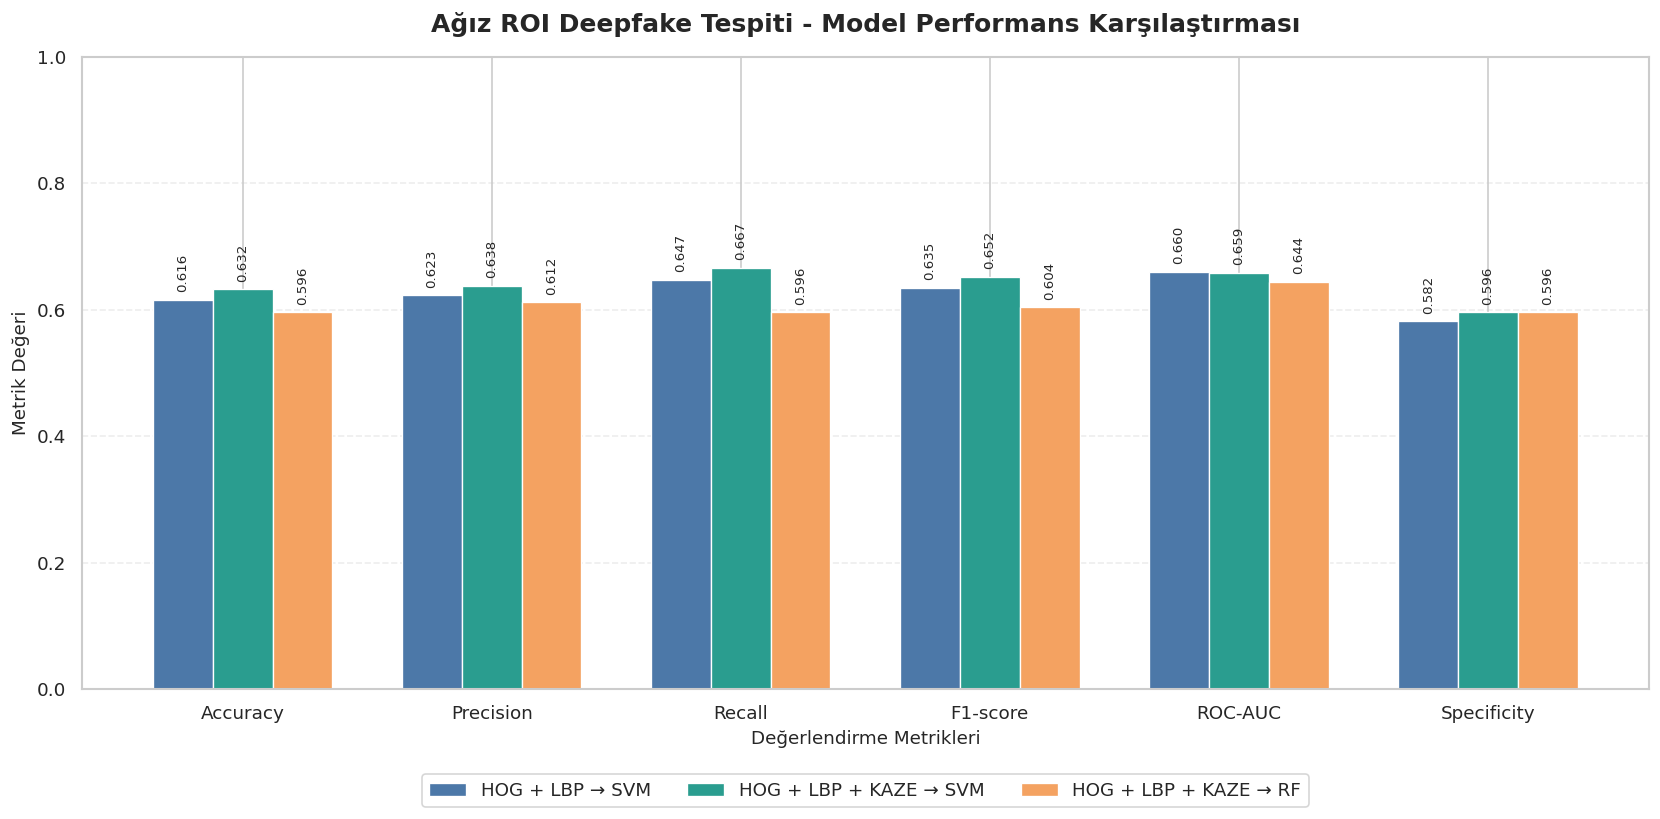

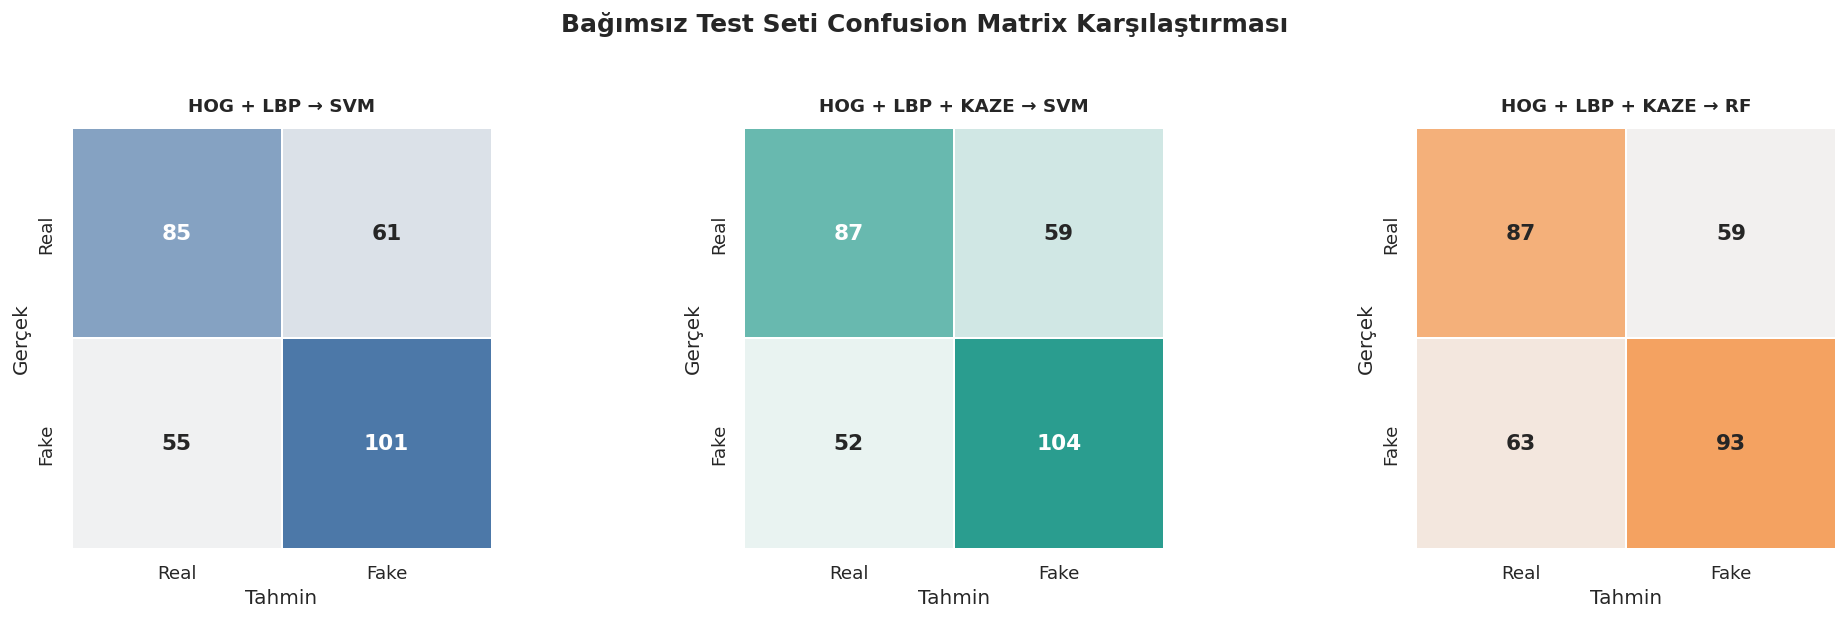

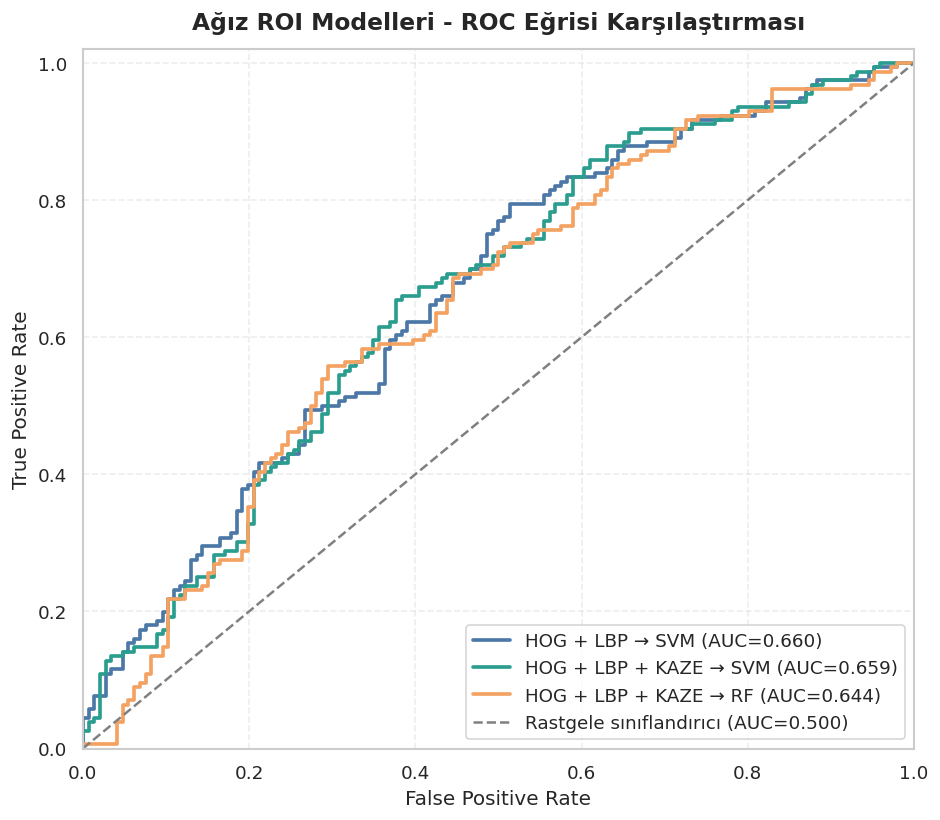


✅ 600 DPI grafikler oluşturuldu.
Metrik grafiği   : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/figures/model_metric_comparison_600dpi.png
Confusion matrix : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/figures/confusion_matrices_600dpi.png
ROC grafiği      : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/figures/roc_curve_comparison_600dpi.png
Sonuç klasörü    : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/figures


In [14]:
# ============================================================
# 14. NİHAİ GRAFİKLER
# Bütün grafikler 600 DPI olarak Drive'a kaydedilir.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    classification_report
)

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Bütün grafiklerde aynı renk düzeni
MODEL_COLORS = {
    "HOG + LBP → SVM": "#4C78A8",
    "HOG + LBP + KAZE → SVM": "#2A9D8F",
    "HOG + LBP + KAZE → RF": "#F4A261"
}

MODEL_NAMES = list(MODEL_COLORS.keys())
MODEL_COLOR_LIST = list(MODEL_COLORS.values())

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. Sayısal model karşılaştırma tablosu
# ------------------------------------------------------------

plot_comparison_df = pd.DataFrame({
    "Model": MODEL_NAMES,

    "Accuracy": [
        baseline_accuracy,
        fused_svm_accuracy,
        rf_accuracy
    ],

    "Precision": [
        baseline_precision,
        fused_svm_precision,
        rf_precision
    ],

    "Recall": [
        baseline_recall,
        fused_svm_recall,
        rf_recall
    ],

    "F1-score": [
        baseline_f1,
        fused_svm_f1,
        rf_f1
    ],

    "ROC-AUC": [
        baseline_auc,
        fused_svm_auc,
        rf_auc
    ],

    "Specificity": [
        baseline_specificity,
        fused_svm_specificity,
        rf_specificity
    ]
})

display(plot_comparison_df)

PLOT_COMPARISON_CSV = (
    RESULTS_DIR /
    "final_model_metrics_for_report.csv"
)

plot_comparison_df.to_csv(
    PLOT_COMPARISON_CSV,
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 2. Metrik karşılaştırma grafiği
# ------------------------------------------------------------

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Specificity"
]

x_positions = np.arange(
    len(metrics_to_plot)
)

bar_width = 0.24

fig, ax = plt.subplots(
    figsize=(14, 7)
)

for model_index, model_name in enumerate(MODEL_NAMES):

    model_values = plot_comparison_df.loc[
        plot_comparison_df["Model"] == model_name,
        metrics_to_plot
    ].values.flatten()

    bar_positions = (
        x_positions +
        (model_index - 1) * bar_width
    )

    bars = ax.bar(
        bar_positions,
        model_values,
        width=bar_width,
        label=model_name,
        color=MODEL_COLORS[model_name],
        edgecolor="white",
        linewidth=0.8
    )

    for bar, value in zip(bars, model_values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_title(
    "Ağız ROI Deepfake Tespiti - Model Performans Karşılaştırması",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Değerlendirme Metrikleri",
    fontsize=11
)

ax.set_ylabel(
    "Metrik Değeri",
    fontsize=11
)

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.0, 1.0)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
    frameon=True
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

plt.tight_layout()

METRIC_GRAPH_FILE = (
    FIGURES_DIR /
    "model_metric_comparison_600dpi.png"
)

plt.savefig(
    METRIC_GRAPH_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ------------------------------------------------------------
# 3. Üç model için confusion matrix
# ------------------------------------------------------------

confusion_matrices = [
    baseline_cm,
    fused_svm_cm,
    rf_cm
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

for axis, matrix, model_name, color in zip(
    axes,
    confusion_matrices,
    MODEL_NAMES,
    MODEL_COLOR_LIST
):
    custom_cmap = sns.light_palette(
        color,
        as_cmap=True
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        ax=axis,
        annot_kws={
            "fontsize": 13,
            "fontweight": "bold"
        }
    )

    axis.set_title(
        model_name,
        fontsize=11,
        fontweight="bold",
        pad=10
    )

    axis.set_xlabel("Tahmin")
    axis.set_ylabel("Gerçek")

fig.suptitle(
    "Bağımsız Test Seti Confusion Matrix Karşılaştırması",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

CONFUSION_GRAPH_FILE = (
    FIGURES_DIR /
    "confusion_matrices_600dpi.png"
)

plt.savefig(
    CONFUSION_GRAPH_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ------------------------------------------------------------
# 4. ROC eğrilerinin karşılaştırılması
# ------------------------------------------------------------

baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_scores
)

fused_fpr, fused_tpr, _ = roc_curve(
    y_test,
    fused_svm_test_scores
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_test_probabilities
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    baseline_fpr,
    baseline_tpr,
    color=MODEL_COLORS["HOG + LBP → SVM"],
    linewidth=2.2,
    label=(
        "HOG + LBP → SVM "
        f"(AUC={baseline_auc:.3f})"
    )
)

ax.plot(
    fused_fpr,
    fused_tpr,
    color=MODEL_COLORS[
        "HOG + LBP + KAZE → SVM"
    ],
    linewidth=2.2,
    label=(
        "HOG + LBP + KAZE → SVM "
        f"(AUC={fused_svm_auc:.3f})"
    )
)

ax.plot(
    rf_fpr,
    rf_tpr,
    color=MODEL_COLORS[
        "HOG + LBP + KAZE → RF"
    ],
    linewidth=2.2,
    label=(
        "HOG + LBP + KAZE → RF "
        f"(AUC={rf_auc:.3f})"
    )
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Rastgele sınıflandırıcı (AUC=0.500)"
)

ax.set_title(
    "Ağız ROI Modelleri - ROC Eğrisi Karşılaştırması",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(linestyle="--", alpha=0.35)

plt.tight_layout()

ROC_GRAPH_FILE = (
    FIGURES_DIR /
    "roc_curve_comparison_600dpi.png"
)

plt.savefig(
    ROC_GRAPH_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# ------------------------------------------------------------
# 5. Ayrıntılı classification report dosyaları
# ------------------------------------------------------------

prediction_sets = {
    "HOG_LBP_SVM": baseline_test_predictions,
    "HOG_LBP_KAZE_SVM": fused_svm_test_predictions,
    "HOG_LBP_KAZE_RF": rf_test_predictions
}

for report_name, predictions in prediction_sets.items():

    report_dictionary = classification_report(
        y_test,
        predictions,
        labels=[0, 1],
        target_names=["real", "fake"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(
        report_dictionary
    ).T

    report_file = (
        RESULTS_DIR /
        f"{report_name}_classification_report.csv"
    )

    report_df.to_csv(
        report_file,
        encoding="utf-8-sig"
    )

print("\n" + "=" * 70)
print("✅ 600 DPI grafikler oluşturuldu.")
print("Metrik grafiği   :", METRIC_GRAPH_FILE)
print("Confusion matrix :", CONFUSION_GRAPH_FILE)
print("ROC grafiği      :", ROC_GRAPH_FILE)
print("Sonuç klasörü    :", FIGURES_DIR)

Run ID: 20260807_1640_mouth_hog_lbp_kaze_seed42
Run klasörü: /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42
✅ Modeller atomik olarak kaydedildi.
✅ Kaydedilen üç model yeniden yüklendi.
✅ Yeniden yüklenen modeller aynı tahminleri üretti.


,experiment_id,model,selected_parameter,accuracy,precision_fake,recall_fake,f1_fake,roc_auc,specificity_real,tn,fp,fn,tp
0,E1,HOG + LBP - RBF-SVM,C=1.0,0.615894,0.623457,0.647436,0.635220,0.659905,0.582192,85,61,55,101
1,E2,HOG + LBP + KAZE - RBF-SVM,C=1.0,0.632450,0.638037,0.666667,0.652038,0.658632,0.595890,87,59,52,104
2,E3,HOG + LBP + KAZE - Random Forest,RF-2,0.596026,0.611842,0.596154,0.603896,0.644099,0.595890,87,59,63,93


✅ 302 örnek için test tahminleri kaydedildi.


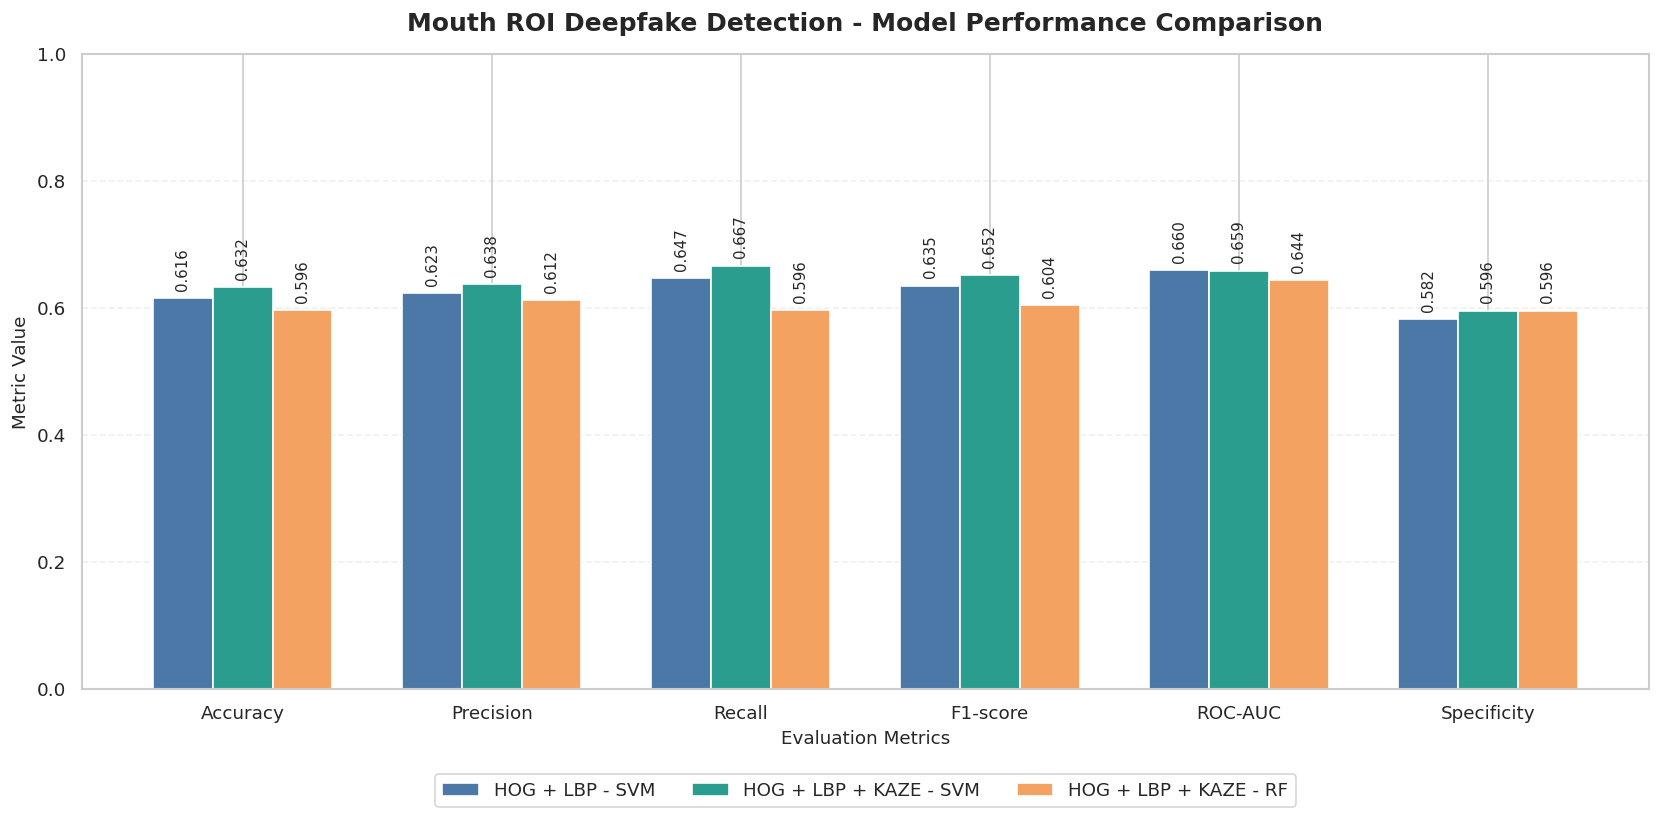

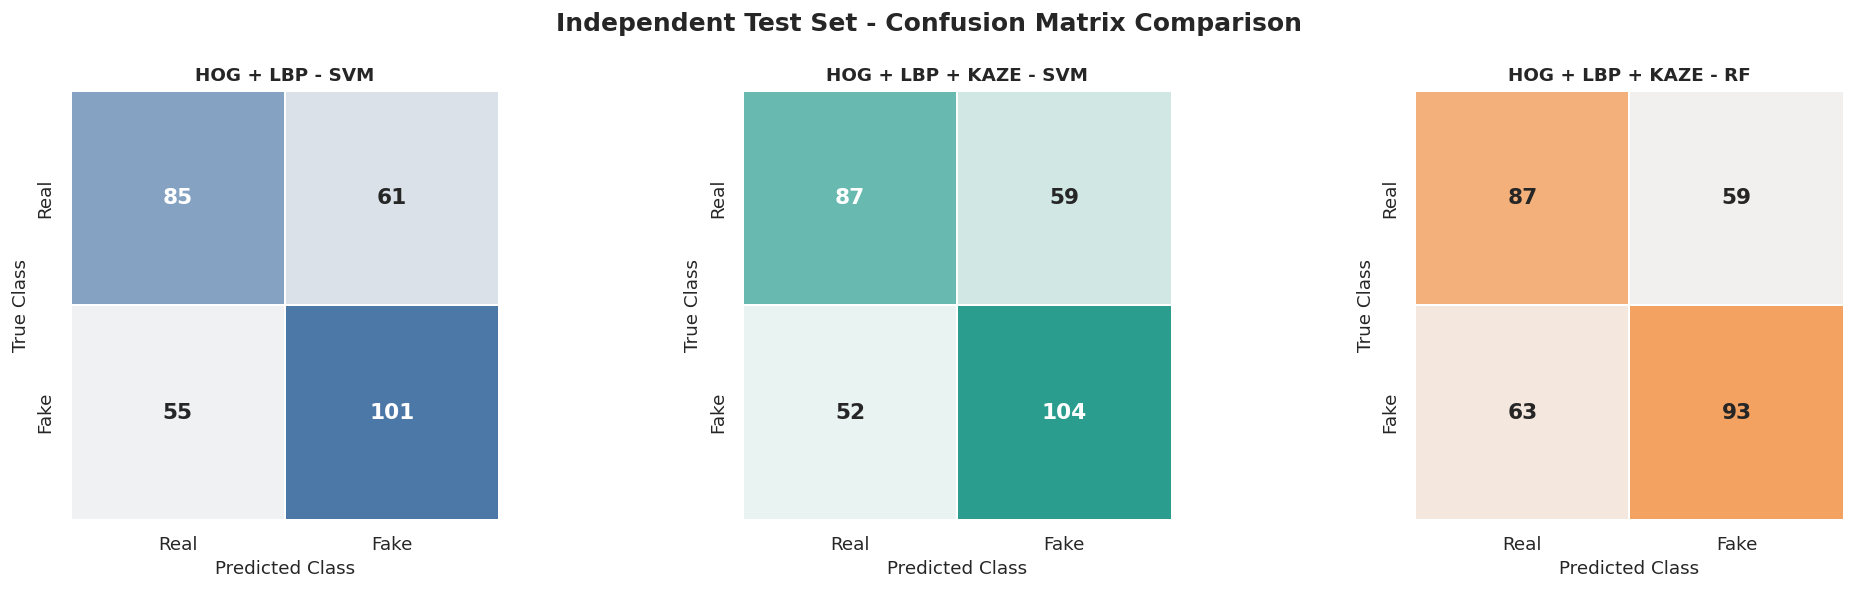

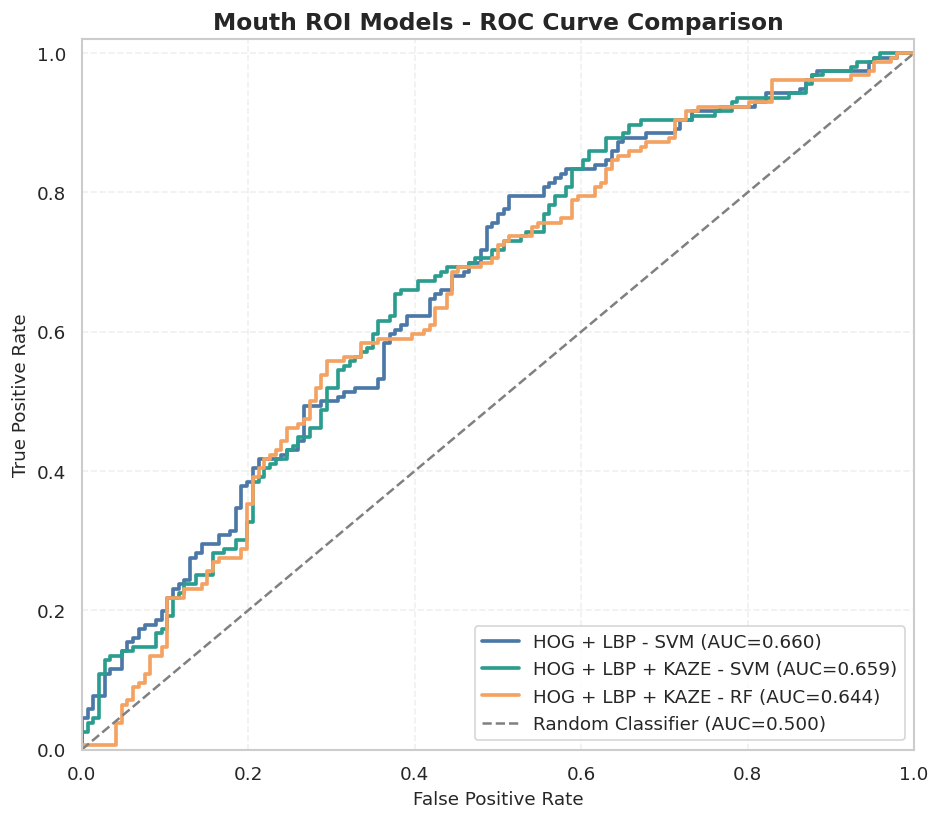

✅ model_performance_20260807_1640_mouth_hog_lbp_kaze_seed42.png: 8302×4096 px
✅ confusion_matrices_20260807_1640_mouth_hog_lbp_kaze_seed42.png: 9279×2952 px
✅ roc_curves_20260807_1640_mouth_hog_lbp_kaze_seed42.png: 4702×4104 px

✅ Standart sonuç paketi oluşturuldu.
Run ID             : 20260807_1640_mouth_hog_lbp_kaze_seed42
Run klasörü        : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42
Model klasörü      : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42/checkpoints
Metrik klasörü     : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42/metrics
Tahmin klasörü     : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42/predictions
İngilizce grafikler: /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/2

In [15]:
# ============================================================
# 15. SSOT STANDARDINA UYGUN NİHAİ SONUÇ PAKETİ
# Modeller yeniden eğitilmez.
# ============================================================

import os
import re
import cv2
import yaml
import joblib
import hashlib
import platform
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from datetime import datetime
from zoneinfo import ZoneInfo
from PIL import Image
from sklearn.metrics import classification_report, roc_curve

# ------------------------------------------------------------
# 1. Standart Sonuçlar klasörü ve Run ID
# ------------------------------------------------------------

STANDARD_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/AISC Çalışmalar/Deneyler/"
    "Dilara/Deney 1/Sonuçlar"
)

STANDARD_RESULTS_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

# Hücre yanlışlıkla tekrar çalıştırılırsa aynı run_id kullanılır
if "RUN_ID" not in globals():
    current_time = datetime.now(
        ZoneInfo("Europe/Istanbul")
    )

    RUN_ID = current_time.strftime(
        "%Y%m%d_%H%M_mouth_hog_lbp_kaze_seed42"
    )

RUN_DIR = STANDARD_RESULTS_ROOT / RUN_ID

CHECKPOINTS_DIR = RUN_DIR / "checkpoints"
METRICS_DIR = RUN_DIR / "metrics"
PREDICTIONS_DIR = RUN_DIR / "predictions"
STANDARD_FIGURES_DIR = RUN_DIR / "figures"
LOGS_DIR = RUN_DIR / "logs"
METADATA_DIR = RUN_DIR / "metadata"

for directory in [
    CHECKPOINTS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    STANDARD_FIGURES_DIR,
    LOGS_DIR,
    METADATA_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Run ID:", RUN_ID)
print("Run klasörü:", RUN_DIR)

# ------------------------------------------------------------
# 2. Atomik model kayıt fonksiyonu
# ------------------------------------------------------------

def atomic_joblib_save(model, target_path):
    """
    Modeli önce geçici dosyaya kaydeder,
    yeniden yükleyerek doğrular ve hedef dosyaya geçirir.
    """

    target_path = Path(target_path)
    temporary_path = Path(
        str(target_path) + ".tmp"
    )

    joblib.dump(
        model,
        temporary_path
    )

    # Geçici dosyanın yüklenebildiğini doğrula
    verified_model = joblib.load(
        temporary_path
    )

    if verified_model is None:
        raise RuntimeError(
            f"Model doğrulaması başarısız: {temporary_path}"
        )

    os.replace(
        temporary_path,
        target_path
    )

    return target_path


BASELINE_STANDARD_MODEL = (
    CHECKPOINTS_DIR /
    "best_hog_lbp_rbf_svm.joblib"
)

FUSED_SVM_STANDARD_MODEL = (
    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_rbf_svm.joblib"
)

RF_STANDARD_MODEL = (
    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_random_forest.joblib"
)

atomic_joblib_save(
    best_baseline_model,
    BASELINE_STANDARD_MODEL
)

atomic_joblib_save(
    best_fused_svm_model,
    FUSED_SVM_STANDARD_MODEL
)

atomic_joblib_save(
    best_rf_model,
    RF_STANDARD_MODEL
)

print("✅ Modeller atomik olarak kaydedildi.")

# ------------------------------------------------------------
# 3. Inference yeniden yükleme testi
# ------------------------------------------------------------

reloaded_baseline_model = joblib.load(
    BASELINE_STANDARD_MODEL
)

reloaded_fused_svm_model = joblib.load(
    FUSED_SVM_STANDARD_MODEL
)

reloaded_rf_model = joblib.load(
    RF_STANDARD_MODEL
)

reloaded_baseline_predictions = (
    reloaded_baseline_model.predict(
        X_test_hog_lbp
    )
)

reloaded_fused_predictions = (
    reloaded_fused_svm_model.predict(
        X_test_fused
    )
)

reloaded_rf_predictions = (
    reloaded_rf_model.predict(
        X_test_fused
    )
)

assert np.array_equal(
    reloaded_baseline_predictions,
    baseline_test_predictions
)

assert np.array_equal(
    reloaded_fused_predictions,
    fused_svm_test_predictions
)

assert np.array_equal(
    reloaded_rf_predictions,
    rf_test_predictions
)

print("✅ Kaydedilen üç model yeniden yüklendi.")
print("✅ Yeniden yüklenen modeller aynı tahminleri üretti.")

# ------------------------------------------------------------
# 4. Nihai metrik tablosu
# ------------------------------------------------------------

standard_metrics_df = pd.DataFrame([
    {
        "experiment_id": "E1",
        "model": "HOG + LBP - RBF-SVM",
        "selected_parameter": f"C={best_baseline_c}",
        "accuracy": baseline_accuracy,
        "precision_fake": baseline_precision,
        "recall_fake": baseline_recall,
        "f1_fake": baseline_f1,
        "roc_auc": baseline_auc,
        "specificity_real": baseline_specificity,
        "tn": int(baseline_cm[0, 0]),
        "fp": int(baseline_cm[0, 1]),
        "fn": int(baseline_cm[1, 0]),
        "tp": int(baseline_cm[1, 1])
    },
    {
        "experiment_id": "E2",
        "model": "HOG + LBP + KAZE - RBF-SVM",
        "selected_parameter": f"C={best_fused_svm_c}",
        "accuracy": fused_svm_accuracy,
        "precision_fake": fused_svm_precision,
        "recall_fake": fused_svm_recall,
        "f1_fake": fused_svm_f1,
        "roc_auc": fused_svm_auc,
        "specificity_real": fused_svm_specificity,
        "tn": int(fused_svm_cm[0, 0]),
        "fp": int(fused_svm_cm[0, 1]),
        "fn": int(fused_svm_cm[1, 0]),
        "tp": int(fused_svm_cm[1, 1])
    },
    {
        "experiment_id": "E3",
        "model": "HOG + LBP + KAZE - Random Forest",
        "selected_parameter": best_rf_configuration["name"],
        "accuracy": rf_accuracy,
        "precision_fake": rf_precision,
        "recall_fake": rf_recall,
        "f1_fake": rf_f1,
        "roc_auc": rf_auc,
        "specificity_real": rf_specificity,
        "tn": int(rf_cm[0, 0]),
        "fp": int(rf_cm[0, 1]),
        "fn": int(rf_cm[1, 0]),
        "tp": int(rf_cm[1, 1])
    }
])

FINAL_METRICS_FILE = (
    METRICS_DIR /
    "final_test_metrics.csv"
)

standard_metrics_df.to_csv(
    FINAL_METRICS_FILE,
    index=False,
    encoding="utf-8-sig"
)

# Validation sonuçlarını da koru
validation_results_df.to_csv(
    METRICS_DIR /
    "hog_lbp_svm_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

fused_validation_results_df.to_csv(
    METRICS_DIR /
    "hog_lbp_kaze_svm_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

rf_validation_results_df.to_csv(
    METRICS_DIR /
    "hog_lbp_kaze_rf_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

display(standard_metrics_df)

# ------------------------------------------------------------
# 5. Örnek bazlı test tahminleri ve hash bilgileri
# ------------------------------------------------------------

def calculate_sha256(file_path):
    sha256_hash = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            sha256_hash.update(block)

    return sha256_hash.hexdigest()


def extract_frame_and_face(file_name):
    match = re.search(
        r"_(\d+)_face(\d+)\.png$",
        file_name
    )

    if match:
        return int(match.group(1)), int(match.group(2))

    return -1, -1


prediction_records = []

for index, image_path in enumerate(test_paths):

    image_path = Path(image_path)
    file_hash = calculate_sha256(image_path)
    frame_index, face_index = extract_frame_and_face(
        image_path.name
    )

    prediction_records.append({
        "sample_id": file_hash[:12],
        # Kaynak video bilgisi mevcut ROI isminden çıkarılamıyor.
        "source_video": "NOT_AVAILABLE",
        "frame_index": frame_index,
        "face_index": face_index,
        "roi_state": "NOT_ANNOTATED",
        "label": (
            "fake"
            if y_test[index] == 1
            else "real"
        ),
        "split": "test",
        "status": "SUCCESS",
        "skip_reason": "",
        "sha256": file_hash,
        "output_path": str(image_path),
        "run_id": RUN_ID,

        "hog_lbp_svm_prediction": (
            "fake"
            if baseline_test_predictions[index] == 1
            else "real"
        ),
        "hog_lbp_svm_score": float(
            baseline_test_scores[index]
        ),

        "hog_lbp_kaze_svm_prediction": (
            "fake"
            if fused_svm_test_predictions[index] == 1
            else "real"
        ),
        "hog_lbp_kaze_svm_score": float(
            fused_svm_test_scores[index]
        ),

        "hog_lbp_kaze_rf_prediction": (
            "fake"
            if rf_test_predictions[index] == 1
            else "real"
        ),
        "hog_lbp_kaze_rf_probability": float(
            rf_test_probabilities[index]
        )
    })

test_predictions_df = pd.DataFrame(
    prediction_records
)

assert len(test_predictions_df) == 302
assert test_predictions_df["sample_id"].is_unique
assert test_predictions_df["output_path"].notna().all()

TEST_PREDICTIONS_FILE = (
    PREDICTIONS_DIR /
    "test_sample_predictions.csv"
)

test_predictions_df.to_csv(
    TEST_PREDICTIONS_FILE,
    index=False,
    encoding="utf-8-sig"
)

print("✅ 302 örnek için test tahminleri kaydedildi.")

# ------------------------------------------------------------
# 6. İngilizce 600 DPI grafikler
# ------------------------------------------------------------

MODEL_NAMES_EN = [
    "HOG + LBP - SVM",
    "HOG + LBP + KAZE - SVM",
    "HOG + LBP + KAZE - RF"
]

MODEL_COLORS = [
    "#4C78A8",
    "#2A9D8F",
    "#F4A261"
]

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC",
    "Specificity"
]

metric_values = np.array([
    [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_auc,
        baseline_specificity
    ],
    [
        fused_svm_accuracy,
        fused_svm_precision,
        fused_svm_recall,
        fused_svm_f1,
        fused_svm_auc,
        fused_svm_specificity
    ],
    [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc,
        rf_specificity
    ]
])

# Metrik karşılaştırması
x_positions = np.arange(len(metric_names))
bar_width = 0.24

fig, ax = plt.subplots(
    figsize=(14, 7)
)

for model_index in range(3):
    positions = (
        x_positions +
        (model_index - 1) * bar_width
    )

    bars = ax.bar(
        positions,
        metric_values[model_index],
        width=bar_width,
        color=MODEL_COLORS[model_index],
        label=MODEL_NAMES_EN[model_index]
    )

    for bar, value in zip(
        bars,
        metric_values[model_index]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.012,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=90
        )

ax.set_title(
    "Mouth ROI Deepfake Detection - Model Performance Comparison",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=11
)

ax.set_ylabel(
    "Metric Value",
    fontsize=11
)

ax.set_xticks(x_positions)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

fig.tight_layout()

METRICS_FIGURE_FILE = (
    STANDARD_FIGURES_DIR /
    f"model_performance_{RUN_ID}.png"
)

fig.savefig(
    METRICS_FIGURE_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# Confusion matrix karşılaştırması
confusion_matrices = [
    baseline_cm,
    fused_svm_cm,
    rf_cm
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

for axis, matrix, model_name, color in zip(
    axes,
    confusion_matrices,
    MODEL_NAMES_EN,
    MODEL_COLORS
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(
            color,
            as_cmap=True
        ),
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        xticklabels=["Real", "Fake"],
        yticklabels=["Real", "Fake"],
        annot_kws={
            "fontsize": 13,
            "fontweight": "bold"
        },
        ax=axis
    )

    axis.set_title(
        model_name,
        fontsize=11,
        fontweight="bold"
    )

    axis.set_xlabel(
        "Predicted Class",
        fontsize=11
    )

    axis.set_ylabel(
        "True Class",
        fontsize=11
    )

fig.suptitle(
    "Independent Test Set - Confusion Matrix Comparison",
    fontsize=15,
    fontweight="bold"
)

fig.tight_layout()

CONFUSION_FIGURE_FILE = (
    STANDARD_FIGURES_DIR /
    f"confusion_matrices_{RUN_ID}.png"
)

fig.savefig(
    CONFUSION_FIGURE_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ROC eğrileri
baseline_fpr, baseline_tpr, _ = roc_curve(
    y_test,
    baseline_test_scores
)

fused_fpr, fused_tpr, _ = roc_curve(
    y_test,
    fused_svm_test_scores
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_test_probabilities
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    baseline_fpr,
    baseline_tpr,
    color=MODEL_COLORS[0],
    linewidth=2.2,
    label=f"{MODEL_NAMES_EN[0]} (AUC={baseline_auc:.3f})"
)

ax.plot(
    fused_fpr,
    fused_tpr,
    color=MODEL_COLORS[1],
    linewidth=2.2,
    label=f"{MODEL_NAMES_EN[1]} (AUC={fused_svm_auc:.3f})"
)

ax.plot(
    rf_fpr,
    rf_tpr,
    color=MODEL_COLORS[2],
    linewidth=2.2,
    label=f"{MODEL_NAMES_EN[2]} (AUC={rf_auc:.3f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier (AUC=0.500)"
)

ax.set_title(
    "Mouth ROI Models - ROC Curve Comparison",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "False Positive Rate",
    fontsize=11
)

ax.set_ylabel(
    "True Positive Rate",
    fontsize=11
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(linestyle="--", alpha=0.30)

fig.tight_layout()

ROC_FIGURE_FILE = (
    STANDARD_FIGURES_DIR /
    f"roc_curves_{RUN_ID}.png"
)

fig.savefig(
    ROC_FIGURE_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

# ------------------------------------------------------------
# 7. Görsel boyut kalite kontrolü
# ------------------------------------------------------------

figure_files = [
    METRICS_FIGURE_FILE,
    CONFUSION_FIGURE_FILE,
    ROC_FIGURE_FILE
]

for figure_file in figure_files:
    with Image.open(figure_file) as image:
        width, height = image.size

    assert min(width, height) >= 600, (
        f"Görsel çözünürlüğü yetersiz: "
        f"{figure_file.name} → {width}x{height}"
    )

    print(
        f"✅ {figure_file.name}: "
        f"{width}×{height} px"
    )

# ------------------------------------------------------------
# 8. Çözümlenmiş konfigürasyon
# ------------------------------------------------------------

resolved_config = {
    "run_id": RUN_ID,
    "region": "mouth",
    "seed": SEED,

    "dataset": {
        "dataset_path": str(DATASET_DIR),
        "total_samples": 2987,
        "train_samples": 2389,
        "validation_samples": 296,
        "test_samples": 302,
        "label_mapping": {
            "real": 0,
            "fake": 1
        },
        "split_source": "pre-existing train/val/test folders",
        "source_video_audit": "PENDING"
    },

    "features": {
        "image_size": list(IMAGE_SIZE),
        "hog": {
            "orientations": HOG_ORIENTATIONS,
            "pixels_per_cell": list(
                HOG_PIXELS_PER_CELL
            ),
            "cells_per_block": list(
                HOG_CELLS_PER_BLOCK
            ),
            "length": HOG_LENGTH
        },
        "lbp": {
            "radius": LBP_RADIUS,
            "points": LBP_POINTS,
            "method": LBP_METHOD,
            "length": LBP_LENGTH
        },
        "kaze": {
            "descriptor_pooling": "mean + standard deviation",
            "length": KAZE_LENGTH
        }
    },

    "models": {
        "hog_lbp_svm": {
            "kernel": "rbf",
            "selected_C": float(best_baseline_c)
        },
        "hog_lbp_kaze_svm": {
            "kernel": "rbf",
            "selected_C": float(best_fused_svm_c)
        },
        "hog_lbp_kaze_random_forest": {
            **best_rf_configuration
        }
    },

    "environment": {
        "python": platform.python_version(),
        "opencv": cv2.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__
    }
}

CONFIG_FILE = (
    RUN_DIR /
    "config_resolved.yaml"
)

TEMP_CONFIG_FILE = Path(
    str(CONFIG_FILE) + ".tmp"
)

with open(
    TEMP_CONFIG_FILE,
    "w",
    encoding="utf-8"
) as config_stream:
    yaml.safe_dump(
        resolved_config,
        config_stream,
        allow_unicode=True,
        sort_keys=False
    )

os.replace(
    TEMP_CONFIG_FILE,
    CONFIG_FILE
)

# ------------------------------------------------------------
# 9. Audit uyarısı ve çalışma özeti
# ------------------------------------------------------------

AUDIT_FILE = (
    LOGS_DIR /
    "audit_summary.txt"
)

audit_text = f"""
Run ID: {RUN_ID}
Region: mouth
Seed: {SEED}

Total ROI samples: 2987
Training samples: 2389
Validation samples: 296
Test samples: 302

Raw/processed ROI files modified: NO
NaN or Inf detected: NO
Duplicate image paths detected: NO
Test set used for model selection: NO
Saved-model inference reload test: PASSED
Figure minimum pixel-size test: PASSED

IMPORTANT PENDING AUDIT:
The source_video field cannot be recovered from the current ROI filenames.
Therefore, video-level train/validation/test isolation has not yet been
independently verified in this notebook. The original ROI extraction
metadata must be located and checked before claiming full SSOT compliance.
""".strip()

with open(
    AUDIT_FILE,
    "w",
    encoding="utf-8"
) as audit_stream:
    audit_stream.write(audit_text)

print("\n" + "=" * 75)
print("✅ Standart sonuç paketi oluşturuldu.")
print("Run ID             :", RUN_ID)
print("Run klasörü        :", RUN_DIR)
print("Model klasörü      :", CHECKPOINTS_DIR)
print("Metrik klasörü     :", METRICS_DIR)
print("Tahmin klasörü     :", PREDICTIONS_DIR)
print("İngilizce grafikler:", STANDARD_FIGURES_DIR)
print("Konfigürasyon      :", CONFIG_FILE)
print("Audit özeti        :", AUDIT_FILE)
print("=" * 75)
print(
    "⚠️ Kalan önemli kontrol: "
    "source_video tabanlı split doğrulaması."
)

In [16]:
# ============================================================
# 16. NİHAİ DOSYA BÜTÜNLÜĞÜ VE TESLİM KONTROLÜ
# ============================================================

import hashlib
import joblib
import yaml
import pandas as pd

from pathlib import Path
from PIL import Image

# ------------------------------------------------------------
# Dosya hash fonksiyonu
# ------------------------------------------------------------

def file_sha256(file_path):
    hash_object = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            hash_object.update(block)

    return hash_object.hexdigest()


# ------------------------------------------------------------
# Zorunlu dosyalar
# ------------------------------------------------------------

required_files = [
    RUN_DIR / "config_resolved.yaml",
    LOGS_DIR / "audit_summary.txt",

    CHECKPOINTS_DIR /
    "best_hog_lbp_rbf_svm.joblib",

    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_rbf_svm.joblib",

    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_random_forest.joblib",

    METRICS_DIR /
    "final_test_metrics.csv",

    METRICS_DIR /
    "hog_lbp_svm_validation_metrics.csv",

    METRICS_DIR /
    "hog_lbp_kaze_svm_validation_metrics.csv",

    METRICS_DIR /
    "hog_lbp_kaze_rf_validation_metrics.csv",

    PREDICTIONS_DIR /
    "test_sample_predictions.csv",

    METRICS_FIGURE_FILE,
    CONFUSION_FIGURE_FILE,
    ROC_FIGURE_FILE
]

print("Zorunlu dosya kontrolü:")
print("-" * 75)

for file_path in required_files:

    assert file_path.exists(), (
        f"Eksik dosya: {file_path}"
    )

    assert file_path.stat().st_size > 0, (
        f"Boş dosya: {file_path}"
    )

    print(
        f"✅ {file_path.relative_to(RUN_DIR)} "
        f"({file_path.stat().st_size / 1024:.1f} KB)"
    )

# ------------------------------------------------------------
# CSV içerik kontrolleri
# ------------------------------------------------------------

verified_metrics_df = pd.read_csv(
    METRICS_DIR /
    "final_test_metrics.csv"
)

verified_predictions_df = pd.read_csv(
    PREDICTIONS_DIR /
    "test_sample_predictions.csv"
)

assert len(verified_metrics_df) == 3
assert len(verified_predictions_df) == 302
assert verified_predictions_df["sample_id"].is_unique
assert set(
    verified_predictions_df["label"].unique()
) == {"real", "fake"}

print("\n✅ Nihai metrik tablosu: 3 model")
print("✅ Test tahmin tablosu: 302 benzersiz örnek")

# ------------------------------------------------------------
# Model yükleme kontrolü
# ------------------------------------------------------------

verified_baseline_model = joblib.load(
    CHECKPOINTS_DIR /
    "best_hog_lbp_rbf_svm.joblib"
)

verified_fused_model = joblib.load(
    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_rbf_svm.joblib"
)

verified_rf_model = joblib.load(
    CHECKPOINTS_DIR /
    "best_hog_lbp_kaze_random_forest.joblib"
)

assert verified_baseline_model is not None
assert verified_fused_model is not None
assert verified_rf_model is not None

print("✅ Üç model dosyası yeniden açılabiliyor.")

# ------------------------------------------------------------
# Config kontrolü
# ------------------------------------------------------------

with open(
    RUN_DIR / "config_resolved.yaml",
    "r",
    encoding="utf-8"
) as config_file:
    verified_config = yaml.safe_load(
        config_file
    )

assert verified_config["run_id"] == RUN_ID
assert verified_config["seed"] == 42
assert verified_config["region"] == "mouth"
assert verified_config["dataset"]["total_samples"] == 2987

print("✅ Config dosyası ve Run ID doğrulandı.")

# ------------------------------------------------------------
# Grafik boyut kontrolleri
# ------------------------------------------------------------

for figure_file in [
    METRICS_FIGURE_FILE,
    CONFUSION_FIGURE_FILE,
    ROC_FIGURE_FILE
]:
    with Image.open(figure_file) as image:
        width, height = image.size

    assert min(width, height) >= 600

    print(
        f"✅ {figure_file.name}: "
        f"{width}×{height} px"
    )

# ------------------------------------------------------------
# Dosya manifesti oluştur
# ------------------------------------------------------------

manifest_records = []

for file_path in sorted(
    path for path in RUN_DIR.rglob("*")
    if path.is_file()
):

    manifest_records.append({
        "run_id": RUN_ID,
        "relative_path": str(
            file_path.relative_to(RUN_DIR)
        ),
        "size_bytes": file_path.stat().st_size,
        "sha256": file_sha256(file_path)
    })

manifest_df = pd.DataFrame(
    manifest_records
)

MANIFEST_FILE = (
    RUN_DIR /
    "file_manifest_sha256.csv"
)

manifest_df.to_csv(
    MANIFEST_FILE,
    index=False,
    encoding="utf-8-sig"
)

assert len(manifest_df) > 0
assert manifest_df["relative_path"].is_unique

print("\nDosya manifesti:")
display(manifest_df)

print("\n" + "=" * 75)
print("✅ DENEY VE DOSYA KONTROLÜ TAMAMLANDI")
print("Run ID       :", RUN_ID)
print("Run klasörü  :", RUN_DIR)
print("Dosya sayısı :", len(manifest_df))
print("Manifest     :", MANIFEST_FILE)
print("En iyi model : HOG + LBP + KAZE - RBF-SVM")
print("Test Accuracy: 0.6325")
print("Test F1      : 0.6520")
print("Test ROC-AUC : 0.6586")
print("=" * 75)

print(
    "⚠️ Açık audit maddesi: "
    "source_video tabanlı split doğrulaması."
)

Zorunlu dosya kontrolü:
---------------------------------------------------------------------------
✅ config_resolved.yaml (1.0 KB)
✅ logs/audit_summary.txt (0.7 KB)
✅ checkpoints/best_hog_lbp_rbf_svm.joblib (107400.5 KB)
✅ checkpoints/best_hog_lbp_kaze_rbf_svm.joblib (108918.2 KB)
✅ checkpoints/best_hog_lbp_kaze_random_forest.joblib (13244.6 KB)
✅ metrics/final_test_metrics.csv (0.6 KB)
✅ metrics/hog_lbp_svm_validation_metrics.csv (0.6 KB)
✅ metrics/hog_lbp_kaze_svm_validation_metrics.csv (0.6 KB)
✅ metrics/hog_lbp_kaze_rf_validation_metrics.csv (0.7 KB)
✅ predictions/test_sample_predictions.csv (115.3 KB)
✅ figures/model_performance_20260807_1640_mouth_hog_lbp_kaze_seed42.png (490.4 KB)
✅ figures/confusion_matrices_20260807_1640_mouth_hog_lbp_kaze_seed42.png (310.8 KB)
✅ figures/roc_curves_20260807_1640_mouth_hog_lbp_kaze_seed42.png (500.9 KB)

✅ Nihai metrik tablosu: 3 model
✅ Test tahmin tablosu: 302 benzersiz örnek
✅ Üç model dosyası yeniden açılabiliyor.
✅ Config dosyası ve Run I

,run_id,relative_path,size_bytes,sha256
0,20260807_1640_mouth_hog_lbp_kaze_seed42,checkpoints/best_hog_lbp_kaze_random_forest.jo...,13562425,b7fdb20dad297434520da4c2334b19332c539619050330...
1,20260807_1640_mouth_hog_lbp_kaze_seed42,checkpoints/best_hog_lbp_kaze_rbf_svm.joblib,111532253,eae56b074c97f2c11ef70e812770ecb4616d6e6c40c041...
2,20260807_1640_mouth_hog_lbp_kaze_seed42,checkpoints/best_hog_lbp_rbf_svm.joblib,109978125,4954ab3ed1807f1f96aed95e0d5c91be262073353ffb59...
3,20260807_1640_mouth_hog_lbp_kaze_seed42,config_resolved.yaml,1055,9e3ac0637225557e6a43026c719a809729dee02073da95...
4,20260807_1640_mouth_hog_lbp_kaze_seed42,figures/confusion_matrices_20260807_1640_mouth...,318295,c02246bc617e0294cb616482ea4c00756b35e1c87c0610...
5,20260807_1640_mouth_hog_lbp_kaze_seed42,figures/model_performance_20260807_1640_mouth_...,502190,557375ab3c707bdd5579b61d5ff071cc6ff9fed0c20971...
6,20260807_1640_mouth_hog_lbp_kaze_seed42,figures/roc_curves_20260807_1640_mouth_hog_lbp...,512873,582b2c0bfd6144da972378b263bbfa133d294c01ac75ff...
7,20260807_1640_mouth_hog_lbp_kaze_seed42,logs/audit_summary.txt,693,427e672358fd30f3c25b268764ce2d680a69e7724bdd2d...
8,20260807_1640_mouth_hog_lbp_kaze_seed42,metrics/final_test_metrics.csv,608,0b97a9aa065e882cffa0b6f6a591c16079caf38495acc8...
9,20260807_1640_mouth_hog_lbp_kaze_seed42,metrics/hog_lbp_kaze_rf_validation_metrics.csv,707,f82ca8b9c73ff5224c77764ea36db5007a8cef46adce04...



✅ DENEY VE DOSYA KONTROLÜ TAMAMLANDI
Run ID       : 20260807_1640_mouth_hog_lbp_kaze_seed42
Run klasörü  : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42
Dosya sayısı : 13
Manifest     : /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Sonuçlar/20260807_1640_mouth_hog_lbp_kaze_seed42/file_manifest_sha256.csv
En iyi model : HOG + LBP + KAZE - RBF-SVM
Test Accuracy: 0.6325
Test F1      : 0.6520
Test ROC-AUC : 0.6586
⚠️ Açık audit maddesi: source_video tabanlı split doğrulaması.


In [17]:
# ============================================================
# SOURCE_VIDEO BİLGİSİNİ İÇEREN METADATA DOSYASINI BULMA
# ============================================================

from pathlib import Path
import pandas as pd

EXPERIMENT_ROOT = Path(
    "/content/drive/MyDrive/AISC Çalışmalar/"
    "Deneyler/Dilara/Deney 1"
)

candidate_files = (
    list(EXPERIMENT_ROOT.rglob("*.csv")) +
    list(EXPERIMENT_ROOT.rglob("*.parquet"))
)

print("Bulunan CSV/Parquet dosyası:", len(candidate_files))
print("-" * 80)

metadata_candidates = []

search_terms = [
    "source",
    "video",
    "frame",
    "face",
    "split",
    "original"
]

for file_path in sorted(candidate_files):
    try:
        if file_path.suffix.lower() == ".csv":
            sample_df = pd.read_csv(
                file_path,
                nrows=5
            )
        else:
            sample_df = pd.read_parquet(
                file_path
            ).head(5)

        columns = [
            str(column)
            for column in sample_df.columns
        ]

        matching_columns = [
            column
            for column in columns
            if any(
                term in column.lower()
                for term in search_terms
            )
        ]

        if matching_columns:
            metadata_candidates.append({
                "file_path": str(file_path),
                "row_preview_count": len(sample_df),
                "all_columns": columns,
                "matching_columns": matching_columns
            })

            print("✅ ADAY DOSYA:")
            print(file_path)
            print("İlgili sütunlar:", matching_columns)
            print("Tüm sütunlar   :", columns)
            print("-" * 80)

    except Exception as error:
        print("⚠️ Okunamadı:", file_path.name)
        print("Hata:", error)

print("\nToplam metadata adayı:", len(metadata_candidates))

if len(metadata_candidates) == 0:
    print(
        "❌ source/video/frame bilgisi içeren "
        "CSV veya Parquet bulunamadı."
    )
else:
    print(
        "✅ Kaynak video bilgisini içerebilecek "
        "metadata dosyaları bulundu."
    )

Bulunan CSV/Parquet dosyası: 39
--------------------------------------------------------------------------------
✅ ADAY DOSYA:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/mouth_hog_lbp_kaze_metadata.csv
İlgili sütunlar: ['split']
Tüm sütunlar   : ['global_index', 'image_path', 'split', 'label', 'class_name', 'kaze_keypoint_count']
--------------------------------------------------------------------------------
✅ ADAY DOSYA:
/content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/test/metadata.csv
İlgili sütunlar: ['source_frame', 'relative_frame_path', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame']
Tüm sütunlar   : ['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 

In [18]:
# Metadata adaylarının yalnızca yollarını göster

print("METADATA ADAYLARI")
print("=" * 80)

for index, candidate in enumerate(
    metadata_candidates,
    start=1
):
    print(f"\n[{index}] {candidate['file_path']}")
    print(
        "İlgili sütunlar:",
        candidate["matching_columns"]
    )

METADATA ADAYLARI

[1] /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/HOG_LBP_KAZE_Results/mouth_hog_lbp_kaze_metadata.csv
İlgili sütunlar: ['split']

[2] /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/test/metadata.csv
İlgili sütunlar: ['source_frame', 'relative_frame_path', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame']

[3] /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/train/metadata.csv
İlgili sütunlar: ['source_frame', 'relative_frame_path', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame']

[4] /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/fake/val/metadata.csv
İlgili sütunlar: ['source_frame', 'relative_frame_path', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame']

[5] /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/De

In [19]:
# ============================================================
# 17. SOURCE VIDEO TABANLI SPLIT DOĞRULAMASI
# Audit, config, predictions ve manifest güncellenir.
# ============================================================

import os
import yaml
import hashlib
import numpy as np
import pandas as pd

from pathlib import Path

MASTER_ROI_METADATA_FILE = (
    DATASET_DIR /
    "metadata.csv"
)

assert MASTER_ROI_METADATA_FILE.exists(), (
    f"Metadata bulunamadı: {MASTER_ROI_METADATA_FILE}"
)

roi_metadata_df = pd.read_csv(
    MASTER_ROI_METADATA_FILE
)

print("Metadata dosyası:", MASTER_ROI_METADATA_FILE)
print("Metadata satır sayısı:", len(roi_metadata_df))
print("Metadata sütunları:")
print(list(roi_metadata_df.columns))

# Zorunlu alanlar
required_metadata_columns = {
    "video_id",
    "split",
    "frame_stem",
    "face_id"
}

missing_columns = (
    required_metadata_columns -
    set(roi_metadata_df.columns)
)

assert not missing_columns, (
    f"Eksik metadata sütunları: {missing_columns}"
)

# Split adlarını standartlaştır
roi_metadata_df["split_normalized"] = (
    roi_metadata_df["split"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "validation": "val",
        "valid": "val"
    })
)

assert set(
    roi_metadata_df["split_normalized"].unique()
) == {"train", "val", "test"}

assert roi_metadata_df["video_id"].notna().all()

# Label/sınıf sütunu varsa video kimliğine ekle
# Böylece real ve fake tarafında aynı kısa video adı varsa karışmaz.
label_column = None

for possible_column in [
    "label",
    "class_name",
    "class",
    "category"
]:
    if possible_column in roi_metadata_df.columns:
        label_column = possible_column
        break

if label_column is not None:
    roi_metadata_df["source_video_key"] = (
        roi_metadata_df[label_column]
        .astype(str)
        .str.lower()
        .str.strip()
        + "::" +
        roi_metadata_df["video_id"]
        .astype(str)
        .str.strip()
    )
else:
    roi_metadata_df["source_video_key"] = (
        roi_metadata_df["video_id"]
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Split başına video kümeleri
# ------------------------------------------------------------

train_video_ids = set(
    roi_metadata_df.loc[
        roi_metadata_df["split_normalized"] == "train",
        "source_video_key"
    ]
)

val_video_ids = set(
    roi_metadata_df.loc[
        roi_metadata_df["split_normalized"] == "val",
        "source_video_key"
    ]
)

test_video_ids = set(
    roi_metadata_df.loc[
        roi_metadata_df["split_normalized"] == "test",
        "source_video_key"
    ]
)

train_val_overlap = (
    train_video_ids &
    val_video_ids
)

train_test_overlap = (
    train_video_ids &
    test_video_ids
)

val_test_overlap = (
    val_video_ids &
    test_video_ids
)

print("\nKaynak video sayıları:")
print("Train:", len(train_video_ids))
print("Val  :", len(val_video_ids))
print("Test :", len(test_video_ids))

print("\nVideo kesişimleri:")
print("Train ∩ Val :", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Val ∩ Test  :", len(val_test_overlap))

assert len(train_val_overlap) == 0, (
    f"Train/Val video sızıntısı: {train_val_overlap}"
)

assert len(train_test_overlap) == 0, (
    f"Train/Test video sızıntısı: {train_test_overlap}"
)

assert len(val_test_overlap) == 0, (
    f"Val/Test video sızıntısı: {val_test_overlap}"
)

print("\n✅ Train ve Validation video kümeleri ayrık.")
print("✅ Train ve Test video kümeleri ayrık.")
print("✅ Validation ve Test video kümeleri ayrık.")
print("✅ Video düzeyinde split doğrulaması PASSED.")

# ------------------------------------------------------------
# Test prediction CSV içindeki source_video alanını güncelle
# ------------------------------------------------------------

prediction_file = (
    PREDICTIONS_DIR /
    "test_sample_predictions.csv"
)

predictions_df = pd.read_csv(
    prediction_file
)

test_roi_metadata = roi_metadata_df[
    roi_metadata_df["split_normalized"] == "test"
].copy()

# frame_stem + face_id anahtarı
def create_metadata_match_key(row):
    try:
        face_id = int(row["face_id"])
        face_suffix = f"_face{face_id:02d}"
    except Exception:
        face_suffix = f"_face{row['face_id']}"

    return (
        str(row["frame_stem"]) +
        face_suffix
    )

test_roi_metadata["match_key"] = (
    test_roi_metadata.apply(
        create_metadata_match_key,
        axis=1
    )
)

source_video_values = []

for output_path in predictions_df["output_path"]:

    file_name = Path(output_path).name

    matches = test_roi_metadata[
        test_roi_metadata["match_key"].apply(
            lambda key: str(key) in file_name
        )
    ]

    if len(matches) == 1:
        source_video_values.append(
            str(matches.iloc[0]["video_id"])
        )
    else:
        source_video_values.append(
            "MATCH_NOT_UNIQUE"
        )

predictions_df["source_video"] = (
    source_video_values
)

unmatched_count = int(
    (
        predictions_df["source_video"] ==
        "MATCH_NOT_UNIQUE"
    ).sum()
)

print(
    "\nEşleştirilemeyen test tahmini:",
    unmatched_count
)

assert unmatched_count == 0, (
    "Bazı test tahminleri metadata ile "
    "benzersiz eşleştirilemedi."
)

# Atomik CSV güncellemesi
temporary_prediction_file = Path(
    str(prediction_file) + ".tmp"
)

predictions_df.to_csv(
    temporary_prediction_file,
    index=False,
    encoding="utf-8-sig"
)

os.replace(
    temporary_prediction_file,
    prediction_file
)

print("✅ Test prediction source_video alanları güncellendi.")

# ------------------------------------------------------------
# config_resolved.yaml audit durumunu güncelle
# ------------------------------------------------------------

config_file = (
    RUN_DIR /
    "config_resolved.yaml"
)

with open(
    config_file,
    "r",
    encoding="utf-8"
) as stream:
    config_data = yaml.safe_load(stream)

config_data["dataset"]["source_video_audit"] = "PASSED"
config_data["dataset"]["source_video_column"] = "video_id"
config_data["dataset"]["roi_metadata_file"] = str(
    MASTER_ROI_METADATA_FILE
)

config_data["dataset"]["unique_source_videos"] = {
    "train": len(train_video_ids),
    "validation": len(val_video_ids),
    "test": len(test_video_ids)
}

config_data["dataset"]["video_overlap_counts"] = {
    "train_validation": len(train_val_overlap),
    "train_test": len(train_test_overlap),
    "validation_test": len(val_test_overlap)
}

temporary_config_file = Path(
    str(config_file) + ".tmp"
)

with open(
    temporary_config_file,
    "w",
    encoding="utf-8"
) as stream:
    yaml.safe_dump(
        config_data,
        stream,
        allow_unicode=True,
        sort_keys=False
    )

os.replace(
    temporary_config_file,
    config_file
)

# ------------------------------------------------------------
# Audit özetini PASSED olarak güncelle
# ------------------------------------------------------------

audit_file = (
    LOGS_DIR /
    "audit_summary.txt"
)

audit_text = f"""
Run ID: {RUN_ID}
Region: mouth
Seed: {SEED}

Total ROI samples: 2987
Training samples: 2389
Validation samples: 296
Test samples: 302

Raw/processed ROI files modified: NO
NaN or Inf detected: NO
Duplicate image paths detected: NO
Test set used for model selection: NO
Saved-model inference reload test: PASSED
Figure minimum pixel-size test: PASSED

VIDEO-LEVEL SPLIT AUDIT: PASSED
Metadata source: {MASTER_ROI_METADATA_FILE}
Video identifier column: video_id
Train source videos: {len(train_video_ids)}
Validation source videos: {len(val_video_ids)}
Test source videos: {len(test_video_ids)}
Train/Validation overlap: {len(train_val_overlap)}
Train/Test overlap: {len(train_test_overlap)}
Validation/Test overlap: {len(val_test_overlap)}
""".strip()

temporary_audit_file = Path(
    str(audit_file) + ".tmp"
)

with open(
    temporary_audit_file,
    "w",
    encoding="utf-8"
) as stream:
    stream.write(audit_text)

os.replace(
    temporary_audit_file,
    audit_file
)

# ------------------------------------------------------------
# Manifesti güncelle
# ------------------------------------------------------------

def calculate_file_hash(file_path):
    hash_object = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            hash_object.update(block)

    return hash_object.hexdigest()

manifest_file = (
    RUN_DIR /
    "file_manifest_sha256.csv"
)

manifest_records = []

for file_path in sorted(
    path for path in RUN_DIR.rglob("*")
    if path.is_file()
    and path != manifest_file
):
    manifest_records.append({
        "run_id": RUN_ID,
        "relative_path": str(
            file_path.relative_to(RUN_DIR)
        ),
        "size_bytes": file_path.stat().st_size,
        "sha256": calculate_file_hash(
            file_path
        )
    })

updated_manifest_df = pd.DataFrame(
    manifest_records
)

temporary_manifest_file = Path(
    str(manifest_file) + ".tmp"
)

updated_manifest_df.to_csv(
    temporary_manifest_file,
    index=False,
    encoding="utf-8-sig"
)

os.replace(
    temporary_manifest_file,
    manifest_file
)

print("\n" + "=" * 75)
print("✅ VIDEO-LEVEL SPLIT AUDIT COMPLETED")
print("Audit result       : PASSED")
print("Train/Val overlap  :", len(train_val_overlap))
print("Train/Test overlap :", len(train_test_overlap))
print("Val/Test overlap   :", len(val_test_overlap))
print("Config updated     :", config_file)
print("Audit updated      :", audit_file)
print("Predictions updated:", prediction_file)
print("Manifest updated   :", manifest_file)
print("=" * 75)

Metadata dosyası: /content/drive/MyDrive/AISC Çalışmalar/Deneyler/Dilara/Deney 1/Ağız/mouth_roi_output/metadata.csv
Metadata satır sayısı: 3098
Metadata sütunları:
['sample_id', 'source_frame', 'relative_frame_path', 'label', 'split', 'video_id', 'frame_stem', 'face_id', 'face_id_scope', 'faces_in_frame', 'mouth_detected', 'mouth_path', 'debug_path', 'landmarks_path', 'mouth_bbox_x1', 'mouth_bbox_y1', 'mouth_bbox_x2', 'mouth_bbox_y2', 'mouth_width_px', 'mouth_height_px', 'landmark_count', 'status', 'error', 'processing_ms']

Kaynak video sayıları:
Train: 2400
Val  : 300
Test : 300

Video kesişimleri:
Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✅ Train ve Validation video kümeleri ayrık.
✅ Train ve Test video kümeleri ayrık.
✅ Validation ve Test video kümeleri ayrık.
✅ Video düzeyinde split doğrulaması PASSED.

Eşleştirilemeyen test tahmini: 0
✅ Test prediction source_video alanları güncellendi.

✅ VIDEO-LEVEL SPLIT AUDIT COMPLETED
Audit result       : PASSED
Train/Val overlap  